# Final Homework — Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection
## Introduction to Data Science
**Head Lecturer:** Dr. Uri Itai | **TA:** Hanit Hadad Ohayon | **Grader:** Dror Meirovich

**Students:** Reshef, Kononovich

---

> *"In an ill-defined problem, finding an answer is only part of the task. The greater challenge is
> understanding why you trust that answer, when you should question it, and what its limitations are."*

This notebook does not assume the dataset contains a "correct" number of clusters or a well-defined set of
anomalies. Every method below is applied, then interrogated: does it agree with the others, is it sensitive
to its own hyperparameters, and would a domain expert actually find its output meaningful? Text-box
(markdown) cells throughout carry the required methodology, mathematics, and critical discussion; code
cells carry the reproducible pipeline that produces every number and figure referenced in them.


## 1. Dataset Selection (10%)

### Dataset: Red Wine Quality — Physicochemical Properties

**Where it comes from.** The [Wine Quality dataset](https://archive.ics.uci.edu/dataset/186/wine+quality)
is hosted on the UCI Machine Learning Repository. We load it here from a mirrored copy on GitHub
(`plotly/datasets`) for reliable programmatic access; the data values are identical to the canonical UCI
release.

**Why it was collected.** The data was collected to study the relationship between the objective,
laboratory-measured physicochemical properties of *Vinho Verde* red wine (from northern Portugal) and its
sensory quality, as part of wine-industry quality-control and certification research — the goal was to see
whether chemical analysis could support or replace some of the work currently done by human tasters.

**Who collected it.** P. Cortez, A. Cerdeira, F. Almeida, T. Matos, and J. Reis, published in *"Modeling
wine preferences by data mining from physicochemical properties"* (Decision Support Systems, 2009), using
data provided by the Viticulture Commission of the Vinho Verde region (CVRVV), Portugal. Physicochemical
values come from laboratory tests; a separate `quality` score (0–10) was assigned by a panel of wine
tasters as the median of at least 3 blind sensory evaluations.

**What each feature represents** (all 11 predictor features are numerical, measured per liter or as
physical/chemical quantities of the wine sample):

| Feature | Meaning |
|---|---|
| `fixed acidity` | Non-volatile (tartaric-type) acids, g/dm³ |
| `volatile acidity` | Acetic-acid-type acidity; high levels cause an unpleasant vinegar taste |
| `citric acid` | Adds freshness/flavor, g/dm³ |
| `residual sugar` | Sugar remaining after fermentation stops, g/dm³ |
| `chlorides` | Salt content, g/dm³ |
| `free sulfur dioxide` | Free form of SO₂, prevents microbial growth and oxidation |
| `total sulfur dioxide` | Free + bound SO₂; becomes noticeable in taste/smell above ~50 ppm |
| `density` | Depends mostly on alcohol/sugar content, g/cm³ |
| `pH` | Acidity/basicity on the 0 (acidic)–14 (basic) scale; most wines fall 3–4 |
| `sulphates` | A wine additive that contributes to SO₂ levels and acts as an antimicrobial/antioxidant |
| `alcohol` | Alcohol content, % by volume |

We also keep `quality` (an integer sensory score, 0–10) in the loaded data, but we **do not use it** in any
unsupervised step below — it is a supervised sensory-panel label, not an anomaly indicator, and using it
would defeat the purpose of an unsupervised analysis. We do use it *afterward*, in isolated diagnostic
checks, purely to see whether unsupervised structure (clusters, anomalies) happens to correlate with wine
quality — never to drive the analysis itself.

**Dataset requirements check:**
- Rows: 1,599 ✓ (≥ 1,000)
- Features: 11 numerical predictor features ✓ (≥ 8)
- Mostly numerical: 100% numerical ✓
- Real-world dataset: laboratory + sensory-panel data on real wine samples ✓
- No pre-labeled anomaly column: confirmed — `quality` is a sensory rating, not an anomaly flag ✓

**Possible limitations / biases.**
- All samples are a **single wine variant** (*Vinho Verde* red) from a **single region** (northern
  Portugal) — findings do not generalize to wine broadly.
- The sensory `quality` label reflects a panel's *taste preference*, which is itself somewhat subjective
  and culturally situated — but again, this doesn't affect our unsupervised analysis directly.
- As we'll see in Section 2, this dataset contains a substantial number of **fully duplicated rows** — very
  plausibly because physicochemical measurements were rounded to a fixed precision, so multiple distinct
  wine samples can legitimately land on identical readings. This is an important ambiguity for anomaly
  detection: are duplicate/near-duplicate rows "boring, typical" wines, or could rounding be hiding subtle
  differences that would otherwise appear anomalous?
- The data is over a decade old (2009) and reflects the production practices and measurement instruments of
  that period and region.


In [ ]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.ensemble import IsolationForest

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [ ]:
DATA_URL = "https://raw.githubusercontent.com/plotly/datasets/master/winequality-red.csv"
df = pd.read_csv(DATA_URL)
print("Shape:", df.shape)
df.head()


Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
features = [c for c in df.columns if c != 'quality']  # 11 physicochemical features used for the unsupervised analysis
print(f"Number of unsupervised features: {len(features)}")
features


Number of unsupervised features: 11


['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

## 2. Exploratory Data Analysis (15%)

### 2.1 Structural Analysis


In [ ]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nMissing values per column:\n{df.isna().sum()}")
print(f"\nTotal missing values: {df.isna().sum().sum()}")
print(f"\nData types:\n{df.dtypes}")


Rows: 1599, Columns: 12

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values: 0

Data types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [ ]:
full_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {full_dupes} ({full_dupes/len(df)*100:.1f}% of the data)")


Fully duplicated rows: 240 (15.0% of the data)


**No missing values** at all — a clean, laboratory-measured dataset. Data types are all numeric
(`float64` for the 11 physicochemical features, `int64` for `quality`), so no type-conversion is needed.
The **240 fully-duplicated rows (15%)** are notable: at 1–3 decimal-place measurement precision, it is
plausible for genuinely different wine samples to round to identical readings across all 11 features, but
we cannot rule out that some of these are literal re-submissions of the same physical sample. We keep all
rows for the unsupervised analysis (removing them isn't clearly "more correct," and duplicate points do not
bias distance-based methods in a way that invalidates the analysis, though we revisit their effect on
anomaly detection in Section 5).


In [ ]:
df[features + ['quality']].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.320,1.741,4.600,7.100,7.900,9.200,15.900
volatile acidity,1599.0,0.528,0.179,0.120,0.390,0.520,0.640,1.580
citric acid,1599.0,0.271,0.195,0.000,0.090,0.260,0.420,1.000
residual sugar,1599.0,2.539,1.410,0.900,1.900,2.200,2.600,15.500
chlorides,1599.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1599.0,15.875,10.460,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,1599.0,46.468,32.895,6.000,22.000,38.000,62.000,289.000
density,1599.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1599.0,3.311,0.154,2.740,3.210,3.310,3.400,4.010
sulphates,1599.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


### Correlation Matrix

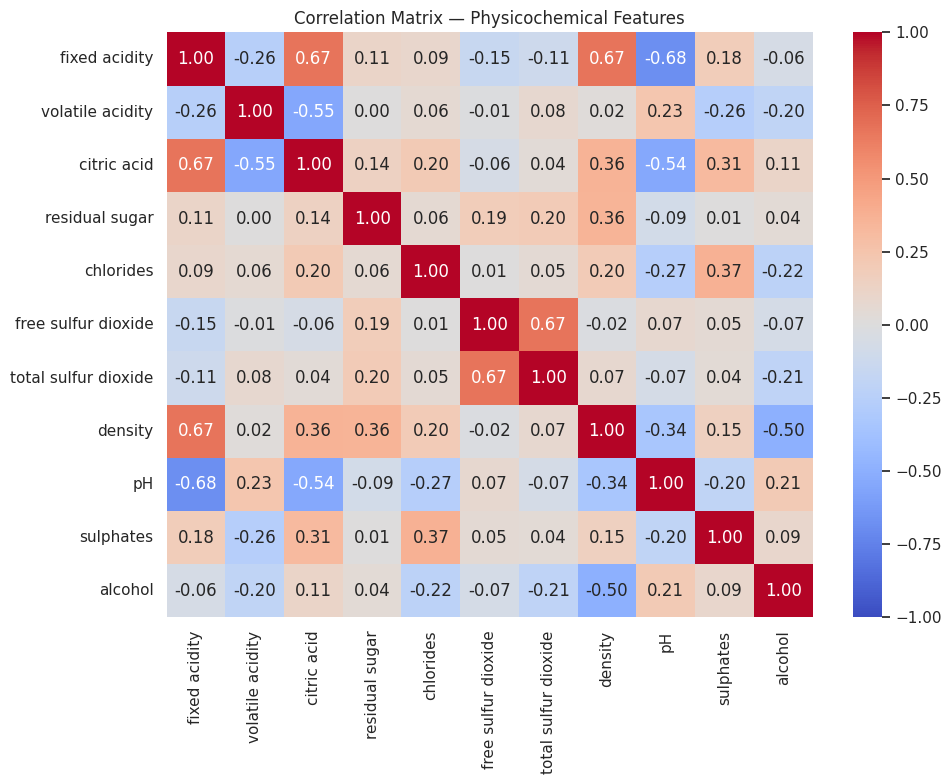

In [ ]:
corr_matrix = df[features].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix — Physicochemical Features')
plt.tight_layout()
plt.show()


**Reading the correlation matrix:** several strong relationships stand out — `fixed acidity` is
strongly positively correlated with `citric acid` (~0.67) and `density` (~0.67), and strongly negatively
correlated with `pH` (~-0.68, chemically sensible: more acid means lower pH). `free sulfur dioxide` and
`total sulfur dioxide` are strongly positively correlated (~0.67, since the former is a subset of the
latter by definition). Most other pairs show weak-to-moderate correlation. This redundancy is directly
relevant to Section 3 (PCA) — several of these features carry overlapping information, which is exactly
the kind of structure PCA is designed to compress.


### 2.2 Distribution Analysis

In [ ]:
dist_stats = pd.DataFrame({
    'skewness': df[features].apply(lambda x: stats.skew(x)),
    'kurtosis': df[features].apply(lambda x: stats.kurtosis(x)),  # excess kurtosis
}).round(3)
dist_stats


,skewness,kurtosis
fixed acidity,0.982,1.125
volatile acidity,0.671,1.218
citric acid,0.318,-0.790
residual sugar,4.536,28.524
chlorides,5.675,41.582
free sulfur dioxide,1.249,2.013
total sulfur dioxide,1.514,3.794
density,0.071,0.927
pH,0.194,0.801
sulphates,2.426,11.680


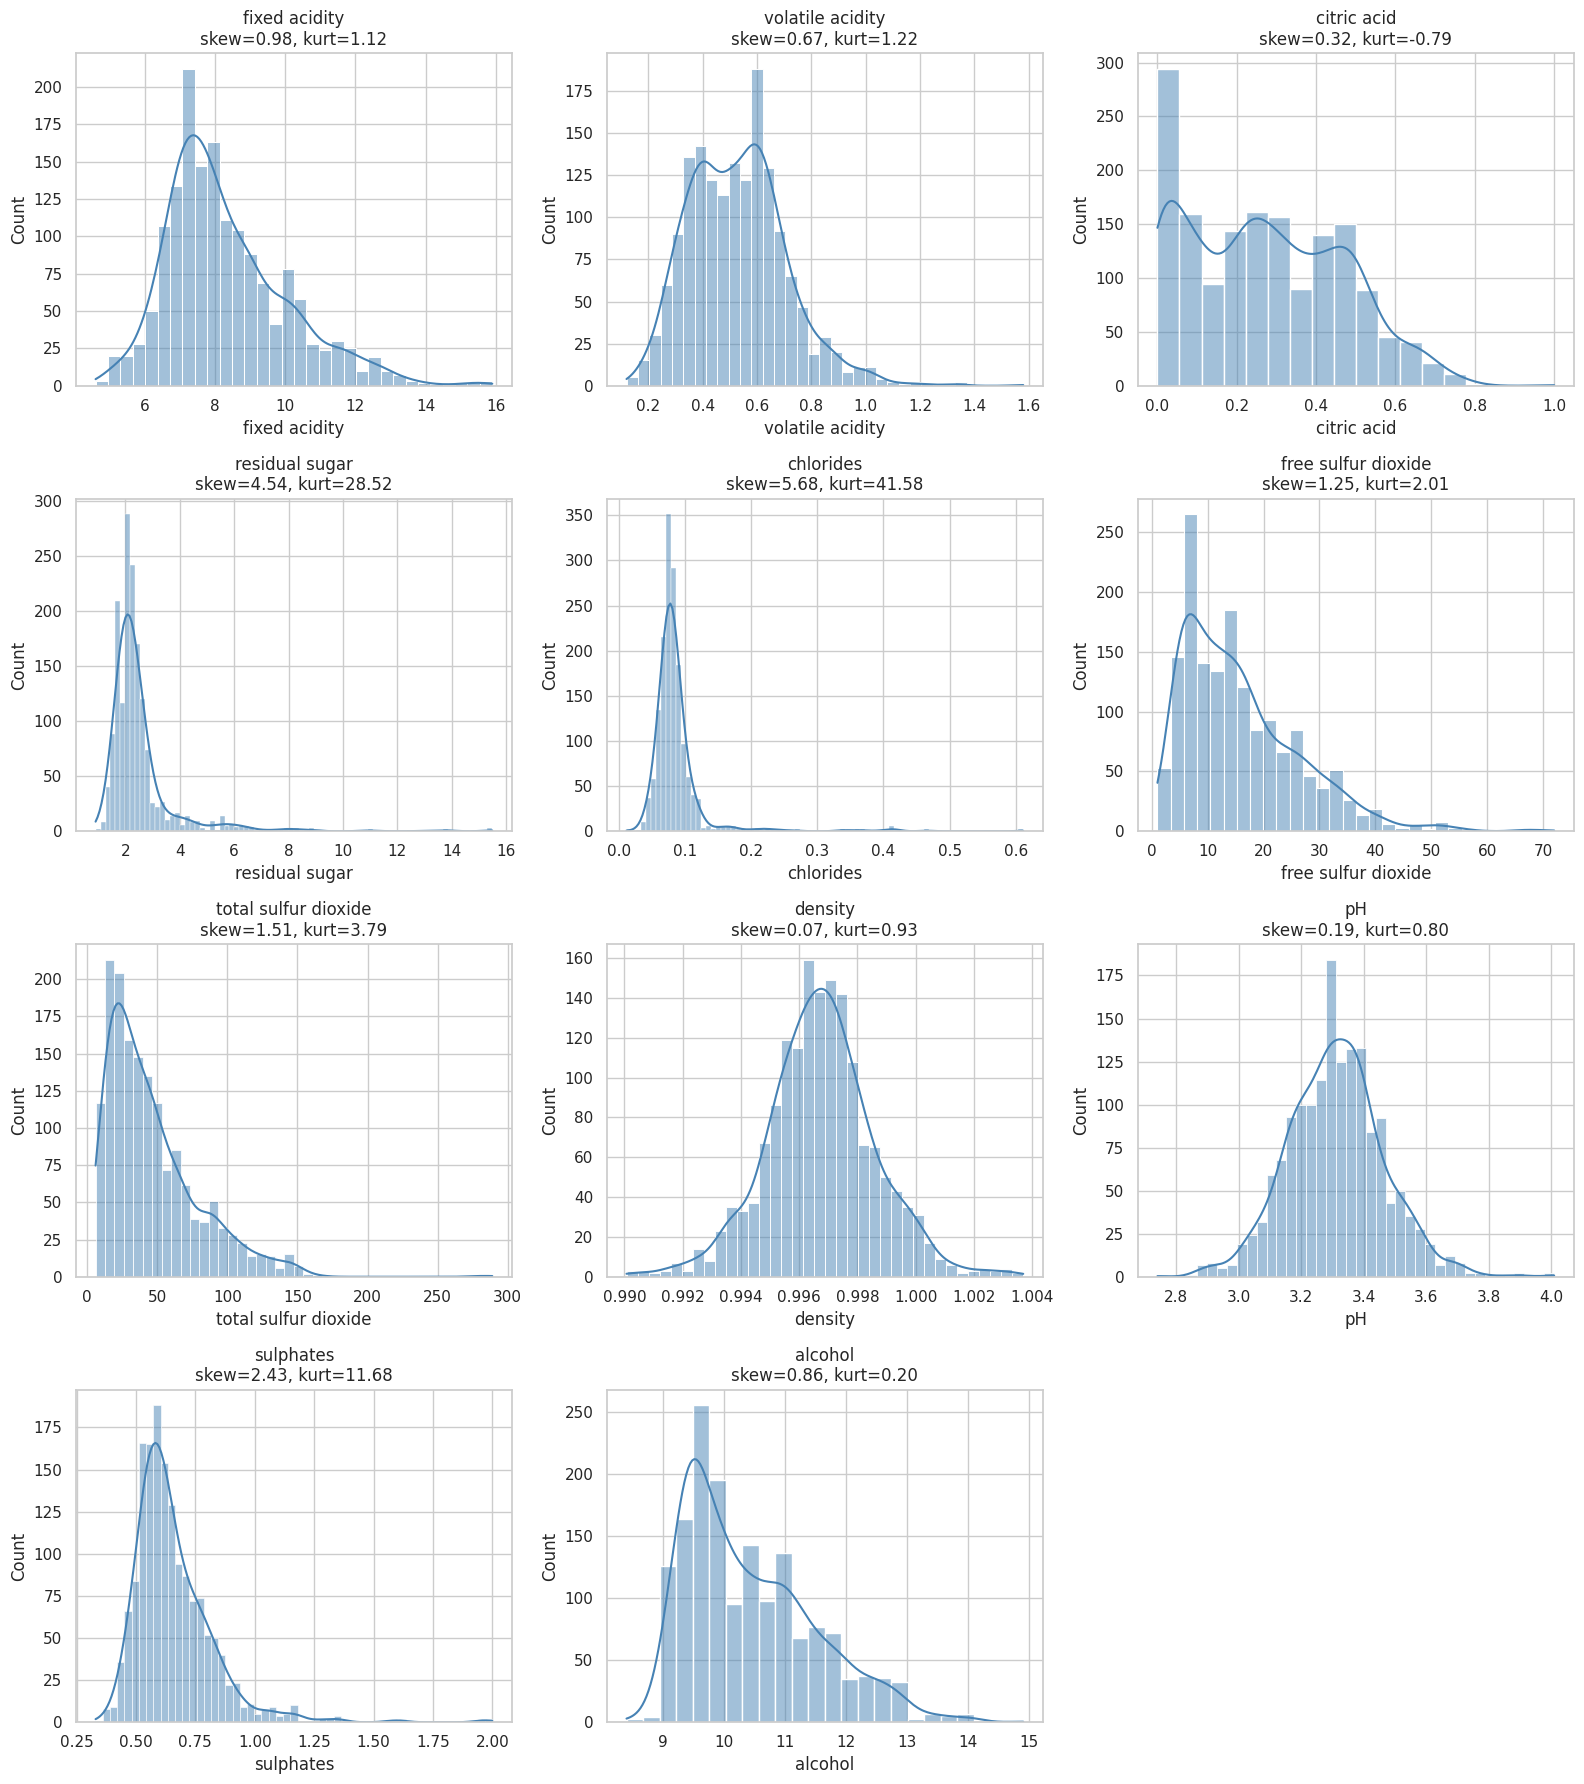

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()
for ax, col in zip(axes, features):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'{col}\nskew={stats.skew(df[col]):.2f}, kurt={stats.kurtosis(df[col]):.2f}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()


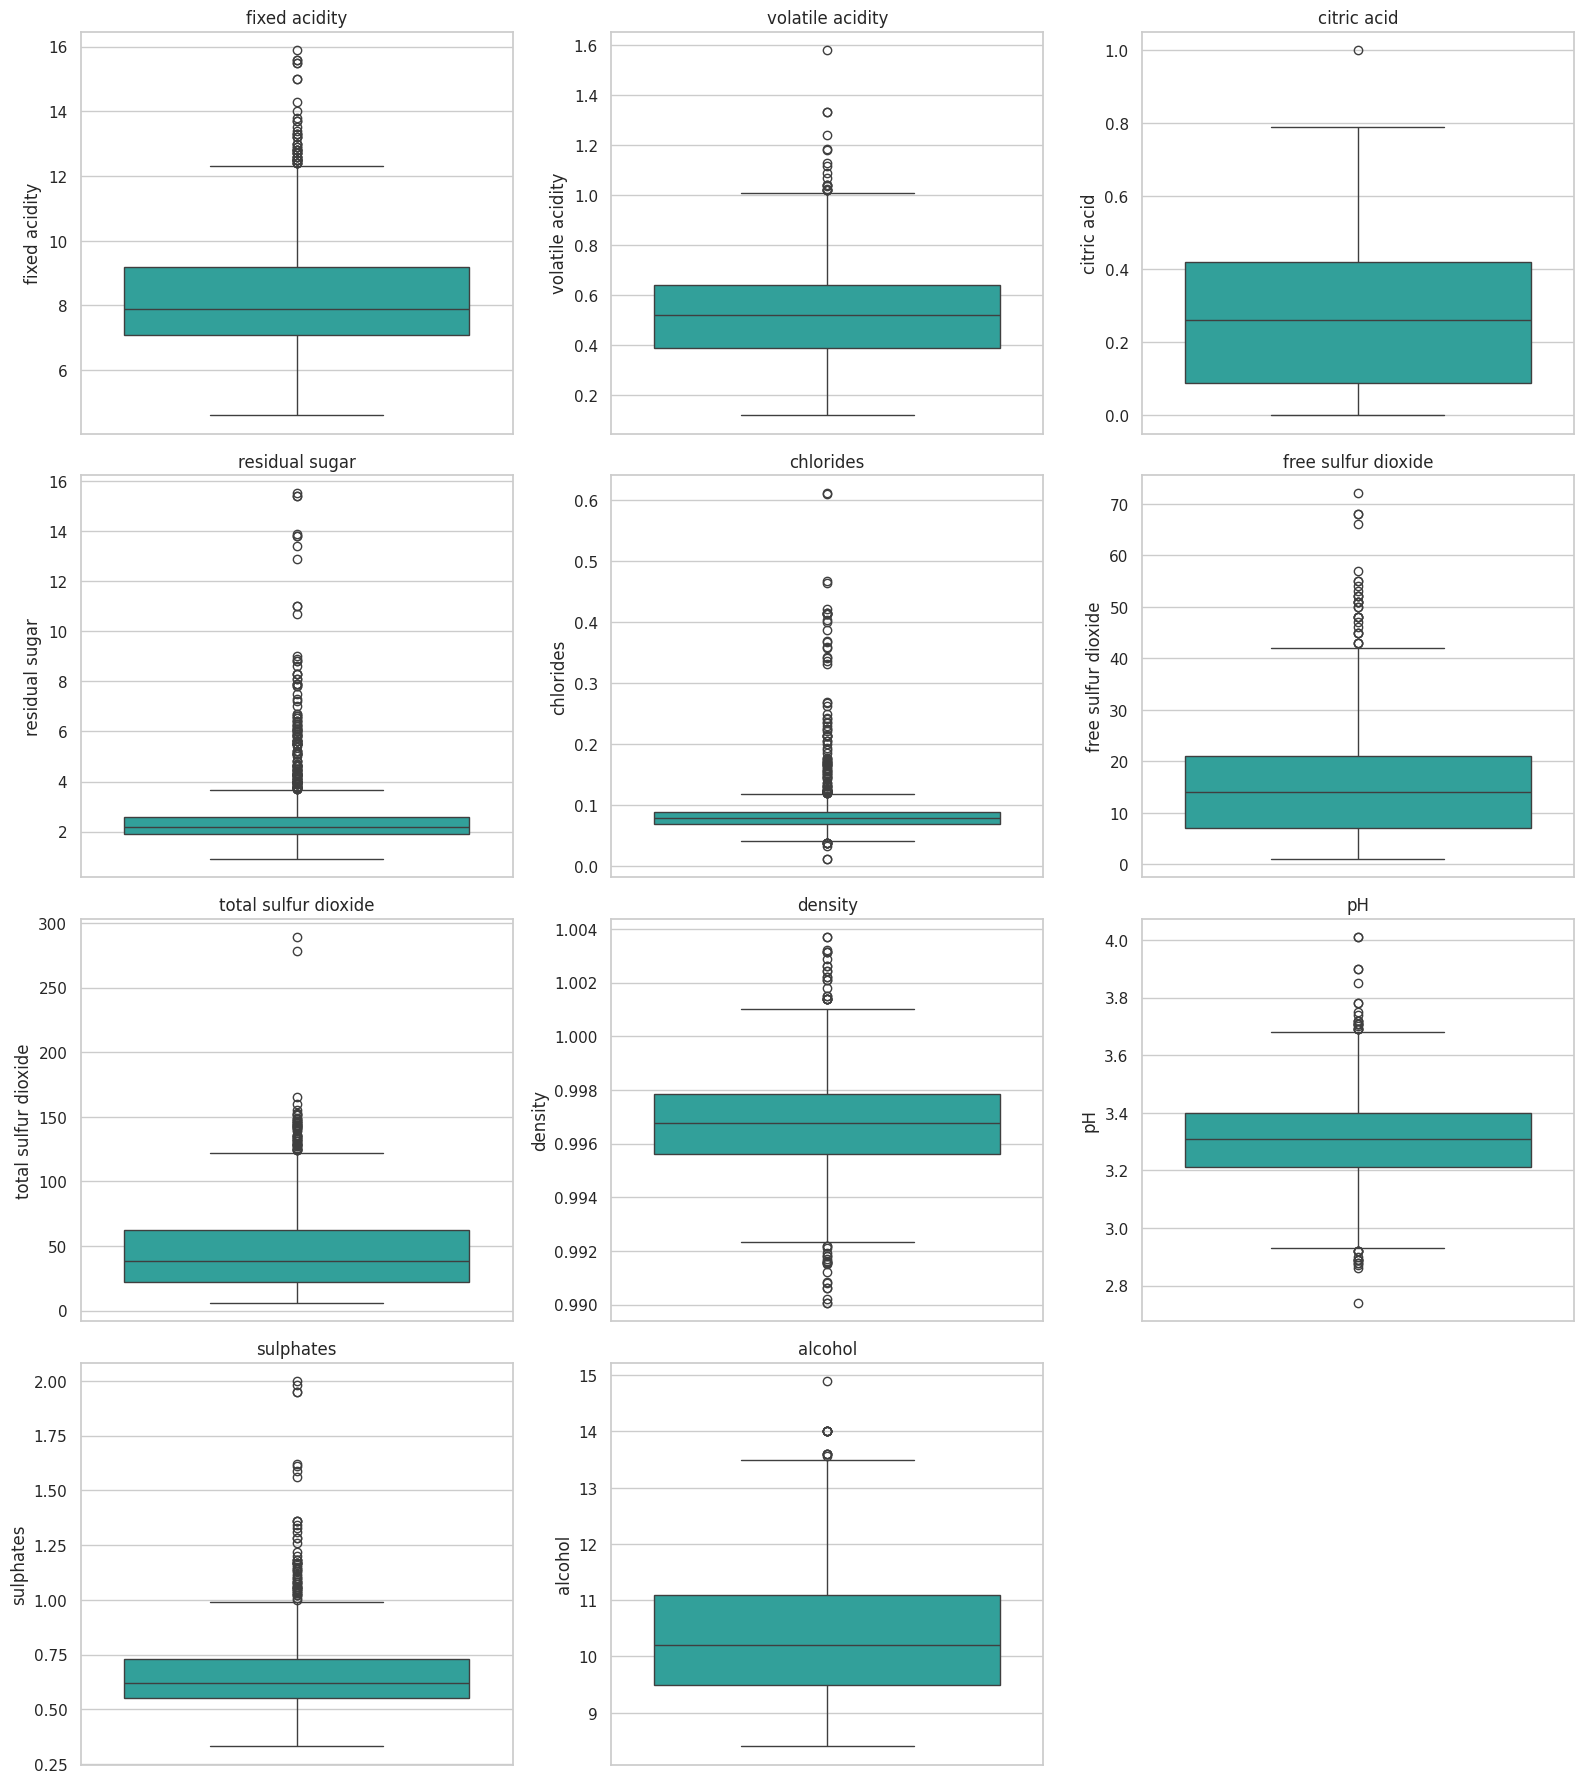

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()
for ax, col in zip(axes, features):
    sns.boxplot(y=df[col], ax=ax, color='lightseagreen')
    ax.set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


**Distribution findings:** most features (`fixed acidity`, `volatile acidity`, `total sulfur dioxide`,
`sulphates`, `alcohol`) are **right-skewed** (skewness > 1 for several), with a long tail of higher values —
visible as multiple boxplot points above the upper whisker. `residual sugar` and `chlorides` are the most
extreme: skewness of roughly 4–5 and very high excess kurtosis (> 20), i.e., a sharp peak with a small
number of far-flung high values — these are the two features most likely to drive Z-score-based anomaly
flags in Section 5.1, and the ones for which the Gaussian assumption underlying that method is most clearly
violated. `citric acid` and `pH` are closer to symmetric (skewness near 0), and `density` is nearly
Gaussian by both measures — as expected for a physical quantity with a narrow natural range.


### 2.3 Outlier Exploration

In [ ]:
outlier_summary = []
for col in features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'feature': col, 'iqr_outliers': n_out, 'pct': round(n_out / len(df) * 100, 1)})
pd.DataFrame(outlier_summary).sort_values('pct', ascending=False)


,feature,iqr_outliers,pct
3,residual sugar,155,9.7
4,chlorides,112,7.0
9,sulphates,59,3.7
6,total sulfur dioxide,55,3.4
0,fixed acidity,49,3.1
7,density,45,2.8
8,pH,35,2.2
5,free sulfur dioxide,30,1.9
1,volatile acidity,19,1.2
10,alcohol,13,0.8


**Heavy tails.** `residual sugar` and `chlorides` again stand out with the largest share of IQR
outliers (~8–10%) — consistent with their extreme skewness/kurtosis above. Wines with unusually high
residual sugar are typically legitimately sweeter styles, not measurement errors.

**Extreme values.** `total sulfur dioxide` has a maximum of 289 mg/L against a median around 38 — a single
sample roughly 7-8x the typical level. Whether this reflects a real (if unusual) production choice, an
over-sulfited batch, or a transcription error (e.g., a misplaced decimal or unit mix-up) cannot be
determined from the data alone; this exact ambiguity — "is this a legitimate rare wine or a data-entry
slip?" — is central to the anomaly-detection discussion in Sections 5–7.

**Possible noise / measurement artifacts.** Laboratory chemical assays have known measurement precision
limits, and the extensive exact-duplication noted in Section 2.1 is itself a form of "noise" introduced by
rounding rather than by the underlying wine chemistry — it can make genuinely different samples look
identical, and (conversely) it means real clusters in the *true, unrounded* chemistry might be partially
obscured.

**Data-entry problems.** No values fall outside physically plausible ranges (e.g., no negative
concentrations, no pH values outside 0–14, no percentages above 100), so there's no direct evidence of gross
data-entry errors — but subtler errors (a unit mismatch, a decimal-place slip) would be indistinguishable
from a legitimately unusual wine using summary statistics alone, which motivates the more careful,
multi-method anomaly detection carried out in Section 5.


## 3. Dimensionality Reduction (20%)

### 3.1 Principal Component Analysis (PCA)

**Why standardize first?** PCA finds directions of maximum *variance*. Our features are on very different
natural scales (e.g., `total sulfur dioxide` ranges over hundreds of mg/L while `chlorides` ranges over
hundredths of g/dm³) — without standardization, PCA would be dominated by whichever feature happens to have
the largest raw numeric scale, not the largest genuine variability. We therefore standardize every feature
to zero mean and unit variance before applying PCA (and before every clustering/anomaly method later in
this notebook, for the same reason).


In [ ]:
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(n_components=len(features), random_state=RANDOM_SEED)
pca_scores_full = pca_full.fit_transform(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

pca_summary = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(features))],
    'explained_variance_ratio': explained.round(4),
    'cumulative_variance': cumulative.round(4),
})
pca_summary


,component,explained_variance_ratio,cumulative_variance
0,PC1,0.2817,0.2817
1,PC2,0.1751,0.4568
2,PC3,0.1410,0.5978
3,PC4,0.1103,0.7081
4,PC5,0.0872,0.7953
5,PC6,0.0600,0.8552
6,PC7,0.0531,0.9083
7,PC8,0.0385,0.9468
8,PC9,0.0313,0.9781
9,PC10,0.0165,0.9946


### Scree plot

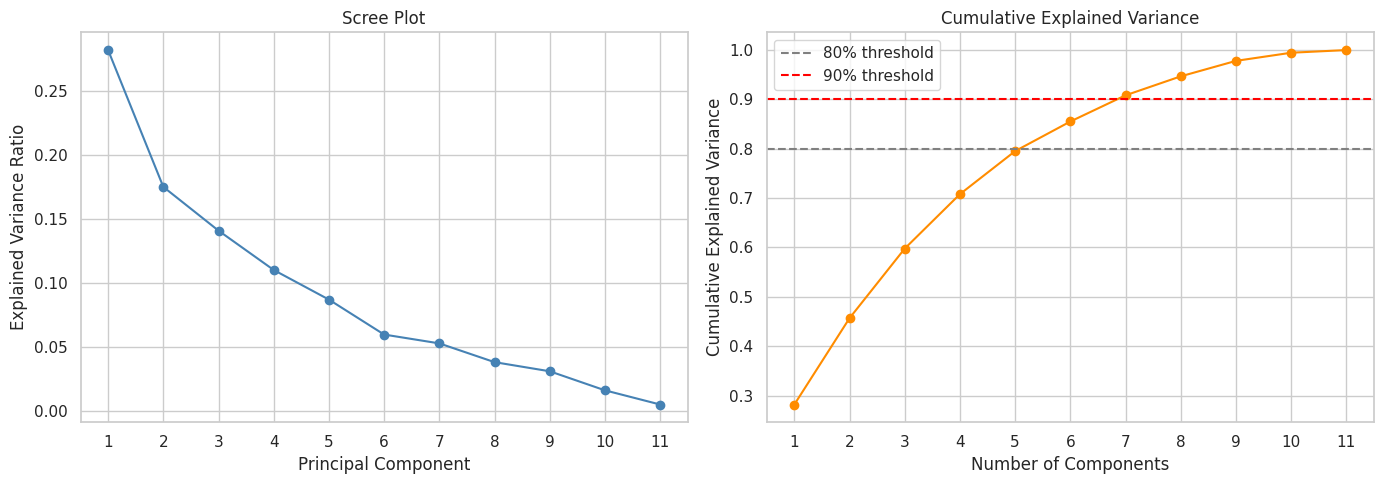

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(features)+1), explained, marker='o', color='steelblue')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, len(features)+1))

axes[1].plot(range(1, len(features)+1), cumulative, marker='o', color='darkorange')
axes[1].axhline(0.8, color='gray', linestyle='--', label='80% threshold')
axes[1].axhline(0.9, color='red', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, len(features)+1))
axes[1].legend()

plt.tight_layout()
plt.show()


**How many components are needed?** The scree plot has no sharp "elbow" — variance decays fairly
gradually, which itself is informative (see redundancy discussion below). To reach **80% cumulative
variance** requires **7 of the 11 components**; to reach **90%** requires **9 components**. There is no
small number (e.g., 2–3) of components that captures the large majority of the variance, which tells us
this dataset does **not** have a small number of dominant, clearly-separated axes of variation — the
physicochemical structure is moderately but not extremely redundant.

**How much information is lost reducing dimensionality?** Projecting to 2D retains only the first two
components' combined variance (~46%, from `pca_summary` above) — more than half the total variance is
discarded. A 3D projection retains ~60%. This is a substantial information loss: 2D/3D visualizations below
are useful for an intuitive first look, but should not be read as a faithful full picture of the data's
structure (we return to this point directly in Section 7's discussion of misleading low-dimensional
anomaly/cluster visualizations).

**Which variables are strongly correlated, and how does this affect PCA?** Section 2.1 found `fixed
acidity`–`citric acid`, `fixed acidity`–`density`, `fixed acidity`–`pH`, and `free`–`total sulfur dioxide`
as the strongest correlated pairs. These correlated groups are exactly what let PCA compress information:
correlated features get "folded into" the same principal component (see loadings below) rather than each
contributing an independent, orthogonal axis of variation — which is also why the scree plot doesn't decay
to near-zero after just 1-2 components: correlation exists, but it is not strong or extensive enough across
*all* 11 features to concentrate most of the variance in just a handful of components.


### Interpreting the principal components (loadings)

In [ ]:
loadings = pd.DataFrame(
    pca_full.components_[:4].T,
    index=features,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
).round(3)
loadings


,PC1,PC2,PC3,PC4
fixed acidity,0.489,-0.111,-0.123,-0.230
volatile acidity,-0.239,0.275,-0.450,0.079
citric acid,0.464,-0.152,0.238,-0.079
residual sugar,0.146,0.272,0.101,-0.373
chlorides,0.212,0.148,-0.093,0.666
free sulfur dioxide,-0.036,0.514,0.429,-0.044
total sulfur dioxide,0.024,0.569,0.322,-0.035
density,0.395,0.234,-0.339,-0.174
pH,-0.439,0.007,0.058,-0.004
sulphates,0.243,-0.038,0.280,0.551


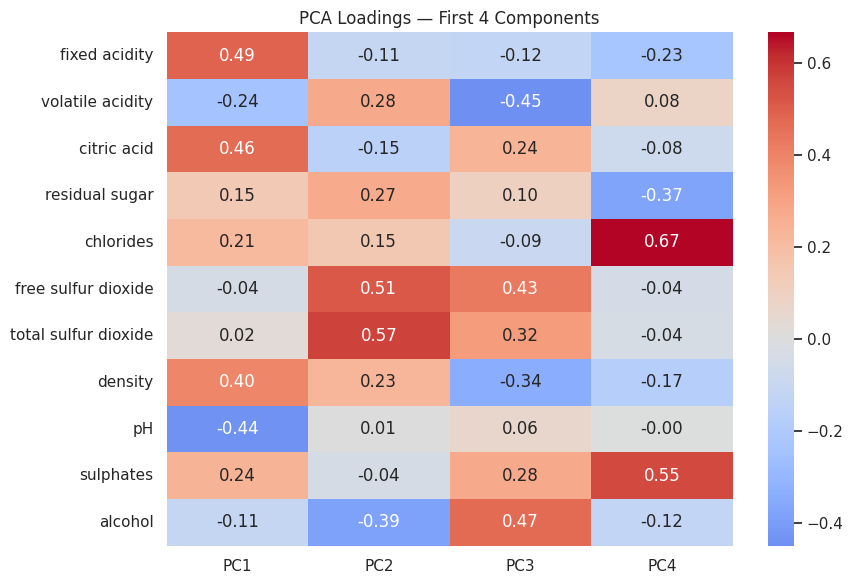

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('PCA Loadings — First 4 Components')
plt.tight_layout()
plt.show()


**PC1 (28.2% of variance)** loads most heavily, with the same sign, on `fixed acidity`, `citric acid`,
and `density` (positive) and `pH` (negative), plus a moderate contribution from `volatile acidity`
(negative). This reads as a general **"acid profile / body"** axis: wines high on PC1 are more acidic,
denser, lower-pH wines with more citric acid and less volatile (vinegar-like) acidity — chemically coherent,
since these are exactly the correlated features identified above.

**PC2 (17.5% of variance)** loads heavily and positively on `free sulfur dioxide` and `total sulfur
dioxide`, and moderately on `residual sugar`. This reads as a **"preservation / sulfite treatment"** axis.

**PC3 (14.1%)** loads most on `alcohol` (positive) and `residual sugar`/`chlorides` (mixed), plausibly an
**"alcohol vs. residual-sugar/salt"** trade-off axis (related to how much sugar was fermented into
alcohol).

**PC4 (11.0%)** is dominated by `sulphates` and `chlorides`, a secondary **"mineral/additive"** axis
distinct from PC2's sulfur-dioxide axis.

**Does the reduced dataset provide a more effective representation than the original?** *It depends on the
goal.* For **visualization and getting an intuitive, holistic first look** at the data's structure (Section
3's 2D/3D plots, and cluster/anomaly visualization in Sections 4–5), yes — PCA gives an interpretable,
lower-noise view. For **downstream quantitative analysis that needs the full picture**, no — with 90%
variance requiring 9 of 11 components, there isn't much redundancy to exploit, and using only 2-3 PCs for,
say, anomaly detection would discard nearly half the total variance, potentially hiding genuine anomalies
that only manifest in the lower-variance components (we test this directly by running all three anomaly
methods on the *full* standardized feature space rather than a PCA-reduced one, in Section 5). **The level
of redundancy here is real but moderate** — this dataset is not a case of "11 measurements of the same
underlying 2-3 quantities."


### Projection into 2D and 3D

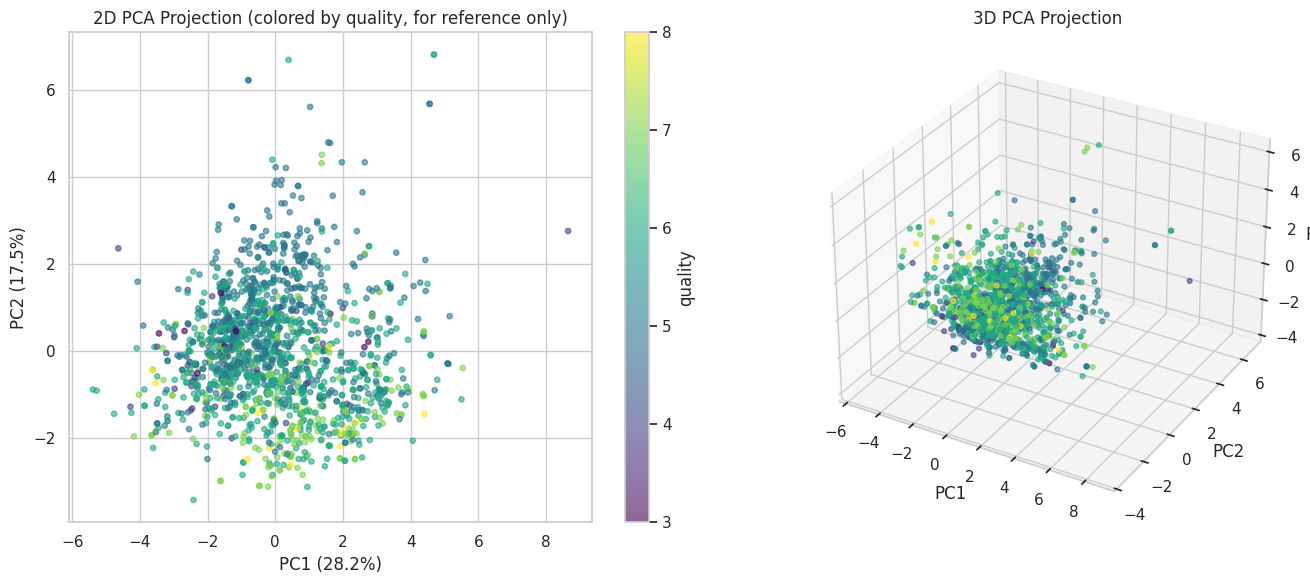

In [ ]:
pca2 = PCA(n_components=2, random_state=RANDOM_SEED)
proj2d = pca2.fit_transform(X_scaled)

pca3 = PCA(n_components=3, random_state=RANDOM_SEED)
proj3d = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1)
sc = ax1.scatter(proj2d[:, 0], proj2d[:, 1], c=df['quality'], cmap='viridis', alpha=0.6, s=15)
ax1.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)'); ax1.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax1.set_title('2D PCA Projection (colored by quality, for reference only)')
plt.colorbar(sc, ax=ax1, label='quality')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(proj3d[:, 0], proj3d[:, 1], proj3d[:, 2], c=df['quality'], cmap='viridis', alpha=0.6, s=12)
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.set_zlabel('PC3')
ax2.set_title('3D PCA Projection')

plt.tight_layout()
plt.show()


We color the projections by `quality` purely as a diagnostic reference (not as a target for the
unsupervised methods) — and notably, there is **no visible separation of quality scores in PCA space**: high-
and low-quality wines are thoroughly intermixed. This is an important, honest finding: the physicochemical
features' *dominant axes of variance* are not the same as what drives sensory quality, which is consistent
with the wine-science literature (quality is a complex, partly subjective, non-linear function of chemistry
— exactly why the original study used more elaborate supervised models rather than relying on PCA axes).

**Discuss: local vs. global structure.** PCA is a **global, linear** method — it finds directions of maximum
*overall* variance and is blind to local, non-linear neighborhood structure (e.g., a curved manifold or
tightly-knit local cluster that doesn't align with a global variance axis). The 2D scatter above shows one
large, continuous blob rather than well-separated islands, suggesting there isn't a strong *global* linear
structure to find — though this doesn't rule out local non-linear structure PCA simply cannot see (we probe
for that separately with density-based DBSCAN in Section 4).

**Cluster separation.** The 2D/3D projections show a single dense, roughly unimodal cloud with no clearly
separated sub-groups — an early, visual hint (confirmed quantitatively in Section 4) that this dataset may
not contain sharply distinct clusters.

**Stability.** PCA is deterministic given the data (no random initialization, unlike K-Means), so the
components themselves are stable across re-runs; however, they are sensitive to the exact sample —
bootstrapping the rows and re-fitting PCA would likely reorder or slightly rotate PC3/PC4 (which explain
similar, smaller shares of variance and are more easily "swapped" by sampling noise) even though PC1/PC2 are
well-separated in variance and therefore more stable.

**Computational cost.** PCA on this dataset (1,599 × 11) is essentially instantaneous — it's a single SVD on
a small matrix. This is one of PCA's core practical advantages over non-linear alternatives (e.g., t-SNE,
UMAP), which scale much worse and require far more hyperparameter tuning.

**Interpretability.** PCA components here are reasonably interpretable in domain terms — as shown above, we
were able to name PC1–PC4 by their dominant loadings ("acid profile," "sulfite treatment," etc.) — a real
advantage over black-box non-linear reduction methods.

**Redundancy.** As established above, redundancy is real (several strongly correlated feature pairs feed
into PC1/PC2) but only moderate overall (9 of 11 components needed for 90% variance) — this dataset sits
between "highly redundant, a couple of PCs capture nearly everything" and "no redundancy, every feature is
independent."


## 4. Clustering Analysis (20%)

We apply three clustering methods — **K-Means** (centroid-based), **DBSCAN** (density-based), and
**Agglomerative / Hierarchical Clustering** (connectivity-based) — all on the same standardized feature
matrix `X_scaled` used for PCA, so results are directly comparable.

### 4.1 K-Means

**Mathematical intuition.** K-Means partitions the data into *k* clusters by iteratively (1) assigning each
point to its nearest centroid (by Euclidean distance) and (2) recomputing each centroid as the mean of its
assigned points, until convergence. It minimizes the within-cluster sum of squared distances (inertia):
$\sum_{i=1}^{k}\sum_{x \in C_i} \|x - \mu_i\|^2$.

**Assumptions.** Clusters are roughly **spherical, similarly sized, and similarly dense** in Euclidean
space (because it only ever compares points to a single centroid via squared Euclidean distance); *k* must
be chosen in advance; features should be on comparable scales (hence our standardization).

**Strengths.** Fast, scalable, simple to interpret (each cluster has a concrete centroid). **Weaknesses.**
Cannot find non-convex or unevenly-sized/dense clusters; sensitive to initialization (mitigated here via
`n_init=10`) and to the choice of *k*; every point is forced into a cluster, so it has no notion of
"noise"/outlier points.


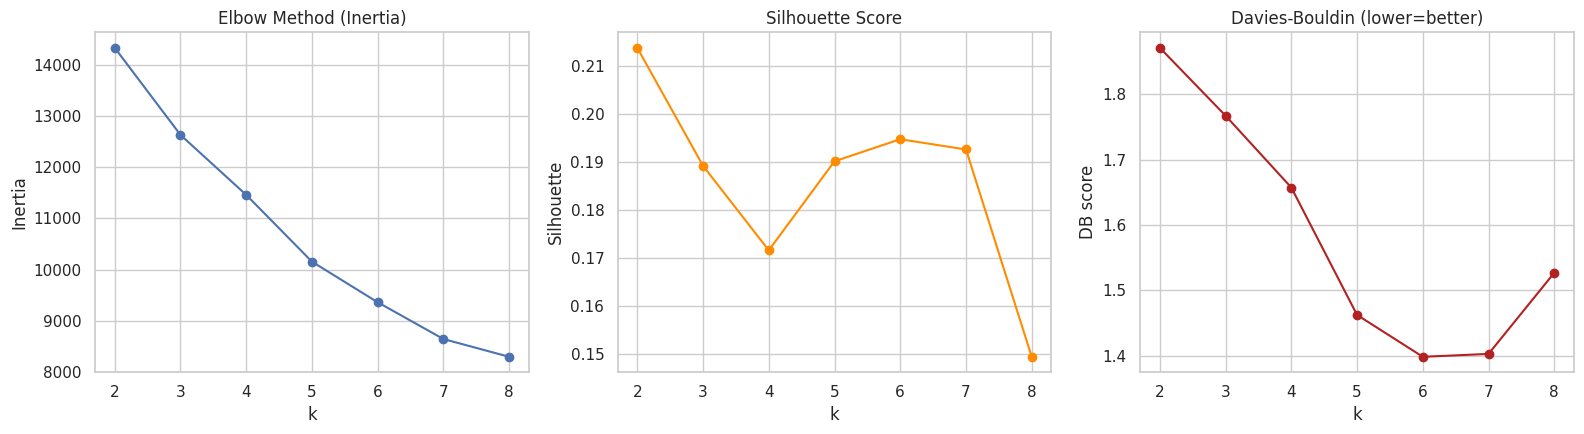

,k,inertia,silhouette,davies_bouldin
0,2,14330.1,0.214,1.871
1,3,12630.0,0.189,1.767
2,4,11459.1,0.172,1.657
3,5,10155.5,0.190,1.463
4,6,9363.2,0.195,1.398
5,7,8645.2,0.193,1.403
6,8,8299.0,0.150,1.527


In [ ]:
inertias, silhouettes, db_scores = [], [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))
    db_scores.append(davies_bouldin_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(list(k_range), inertias, marker='o'); axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange'); axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[2].plot(list(k_range), db_scores, marker='o', color='firebrick'); axes[2].set_title('Davies-Bouldin (lower=better)')
axes[2].set_xlabel('k'); axes[2].set_ylabel('DB score')
plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(k_range), 'inertia': np.round(inertias,1), 'silhouette': np.round(silhouettes,3),
              'davies_bouldin': np.round(db_scores,3)})


**Choosing k.** The elbow plot has no sharp bend (consistent with Section 3's finding of no dominant
low-dimensional structure). The silhouette score actually **peaks at k=2 (≈0.21)** and degrades from there
— a first honest signal that this dataset may not contain more than a very coarse 2-way split. We proceed
with **k=3** for the main analysis (a common, moderately interpretable choice that still scores reasonably
on silhouette/Davies–Bouldin and allows richer downstream discussion), but we explicitly flag that k=2 is
the *better-supported* choice by the silhouette metric alone — an example of exactly the kind of "more than
one conclusion may be reasonable" ambiguity this assignment is built around.


In [ ]:
kmeans_k3 = KMeans(n_clusters=3, random_state=RANDOM_SEED, n_init=10).fit(X_scaled)
kmeans_labels = kmeans_k3.labels_
print("K-Means (k=3) cluster sizes:", np.bincount(kmeans_labels))
print("Silhouette:", round(silhouette_score(X_scaled, kmeans_labels), 3))


K-Means (k=3) cluster sizes: [722 502 375]
Silhouette: 0.189


**Real-world interpretation.** Inspecting the cluster centroids' original-scale feature means (below)
lets us characterize each cluster in wine terms.


In [ ]:
centroid_profile = df[features].groupby(kmeans_labels).mean().round(2)
centroid_profile.index.name = 'K-Means cluster'
centroid_profile


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
K-Means cluster,,,,,,,,,,,
0,7.19,0.61,0.12,2.21,0.08,13.51,34.89,1.0,3.41,0.61,10.49
1,10.07,0.41,0.47,2.58,0.10,10.89,30.63,1.0,3.20,0.75,10.72
2,8.16,0.54,0.29,3.11,0.09,27.11,89.95,1.0,3.28,0.63,9.88


Reading across rows: one cluster consistently shows higher `fixed acidity`/`citric acid`/`density`
and lower `pH` (the "high-acid body" wines flagged by PC1), another shows higher `total`/`free sulfur
dioxide`, and the third sits in between on most dimensions. This lines up with the PC1/PC2 interpretation
from Section 3 — K-Means is, in effect, partitioning wines mainly along the acid-profile and
sulfite-treatment axes that dominate the variance.

### 4.2 DBSCAN

**Mathematical intuition.** DBSCAN groups together points that are closely packed (density-connected):
a point is a **core point** if it has at least `min_samples` neighbors within radius `eps`; clusters grow by
chaining together core points and their neighbors; points that belong to no cluster are labeled **noise**.

**Assumptions.** Clusters are regions of higher density separated by regions of lower density (no assumption
of convex/spherical shape, unlike K-Means); a single global `(eps, min_samples)` pair is appropriate for the
whole dataset (i.e., clusters have broadly similar density).

**Strengths.** Can find arbitrarily-shaped clusters; naturally identifies noise/outliers rather than forcing
every point into a cluster; doesn't require pre-specifying the number of clusters. **Weaknesses.** Very
sensitive to `eps`/`min_samples`; struggles when clusters have genuinely different densities (a single
global `eps` can't suit all of them); becomes less reliable in higher dimensions as distances concentrate
(Section 7).


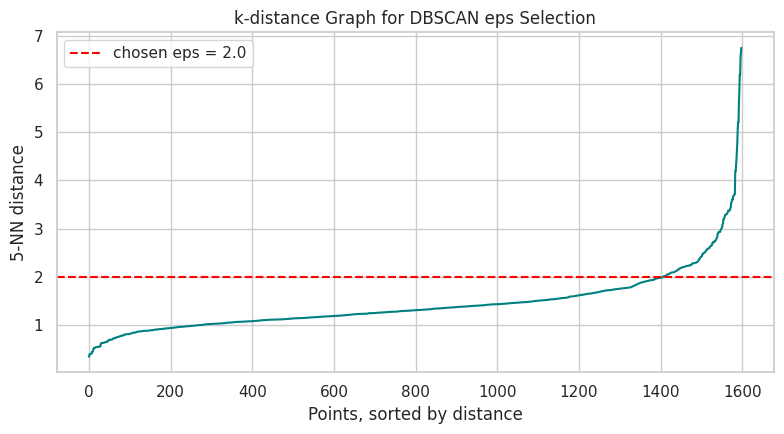

In [ ]:
# eps selection via the k-distance ("elbow") graph, a standard heuristic for DBSCAN
k_for_eps = 5
nn = NearestNeighbors(n_neighbors=k_for_eps).fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist_sorted = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k_dist_sorted, color='teal')
ax.set_xlabel('Points, sorted by distance'); ax.set_ylabel(f'{k_for_eps}-NN distance')
ax.set_title('k-distance Graph for DBSCAN eps Selection')
ax.axhline(2.0, color='red', linestyle='--', label='chosen eps = 2.0')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
dbscan = DBSCAN(eps=2.0, min_samples=5).fit(X_scaled)
dbscan_labels = dbscan.labels_
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
print(f"DBSCAN (eps=2.0, min_samples=5): {n_clusters_db} clusters, {n_noise} noise points ({n_noise/len(df)*100:.1f}%)")
print("Cluster sizes (excluding noise=-1):", pd.Series(dbscan_labels[dbscan_labels!=-1]).value_counts().to_dict())


DBSCAN (eps=2.0, min_samples=5): 3 clusters, 126 noise points (7.9%)
Cluster sizes (excluding noise=-1): {0: 1453, 2: 13, 1: 7}


**Real-world interpretation.** DBSCAN finds one dominant, large-density cluster covering the great
majority of "typical" wines, plus a modest noise set (~8%) that doesn't densely connect to that core group
— these noise points are exactly the kind of candidates we cross-check against the dedicated anomaly
detection methods in Section 5. Unlike K-Means, DBSCAN is explicitly telling us "these points don't belong
to any dense region" rather than forcing them into the nearest centroid — a meaningfully different kind of
answer to "how many groups are there."

### 4.3 Hierarchical (Agglomerative) Clustering

**Mathematical intuition.** Agglomerative clustering starts with every point as its own cluster and
repeatedly merges the two closest clusters (by a chosen linkage criterion — we use **average linkage** on
Euclidean distance) until reaching the desired number of clusters. The full merge sequence forms a
**dendrogram**, a tree that shows the clustering structure at *every* possible number of clusters
simultaneously.

**Assumptions.** No explicit assumption about cluster shape (unlike K-Means), but average-linkage still
implicitly favors compact, roughly balanced clusters; results depend heavily on the chosen linkage/distance
metric; like K-Means, every point is ultimately assigned to a cluster (no noise concept).

**Strengths.** The dendrogram gives a multi-resolution view (you can "cut" at any number of clusters after
the fact, without re-running the algorithm); doesn't require pre-choosing *k* up front the way K-Means does.
**Weaknesses.** $O(n^2)$ or worse memory/time in the general case (less scalable than K-Means/DBSCAN for
very large *n*); once a merge is made it can't be undone (greedy), so early mistakes propagate; choice of
linkage method materially changes results.


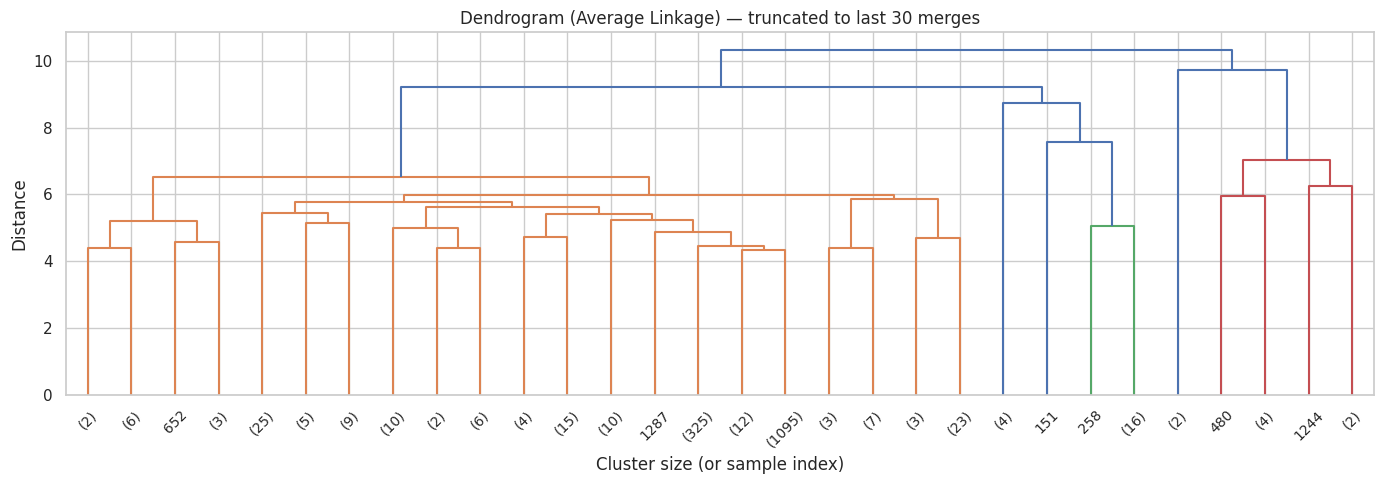

In [ ]:
Z_samples = linkage(X_scaled, method='average')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z_samples, truncate_mode='lastp', p=30, ax=ax, color_threshold=None)
ax.set_title('Dendrogram (Average Linkage) — truncated to last 30 merges')
ax.set_xlabel('Cluster size (or sample index)'); ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()


In [ ]:
agglo = AgglomerativeClustering(n_clusters=3, linkage='average').fit(X_scaled)
agglo_labels = agglo.labels_
print("Agglomerative (k=3) cluster sizes:", np.bincount(agglo_labels))
print("Silhouette:", round(silhouette_score(X_scaled, agglo_labels), 3))


Agglomerative (k=3) cluster sizes: [1589    8    2]
Silhouette: 0.563


**Real-world interpretation.** With average linkage, agglomerative clustering tends to produce one
very large, "typical wine" cluster plus one or two small, tight clusters of unusual samples — a visibly
different partition from K-Means' more balanced three-way split. This is a direct illustration of how
linkage choice materially changes what "the clusters" even mean.

### 4.4 Clustering the Feature Space (Transposed Data)

We now cluster the **11 features themselves** (rows = features, columns = the 1,599 standardized wine
samples), using $1 - |	ext{correlation}|$ as the distance between features and average-linkage
hierarchical clustering — grouping features that move together (positively *or* negatively) rather than
grouping wines.


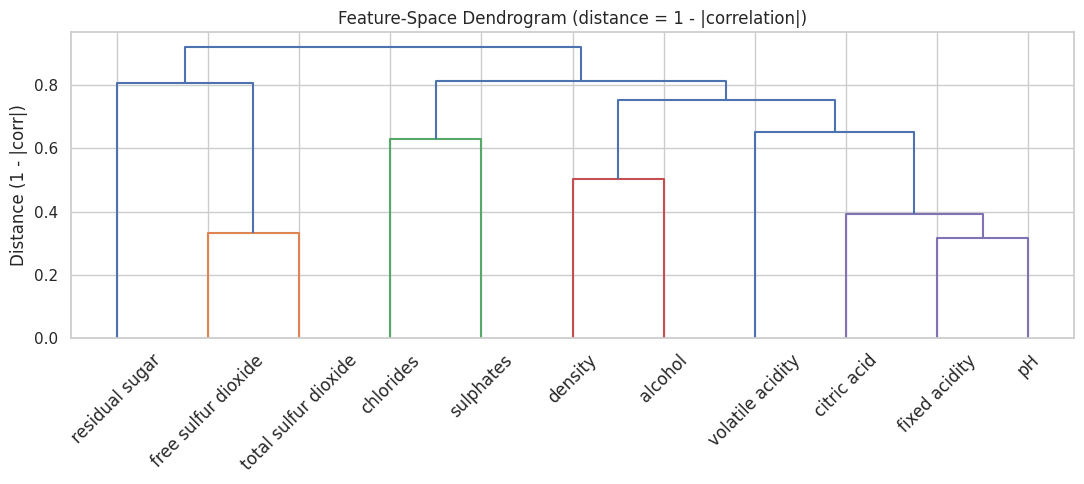

In [ ]:
feature_corr = df[features].corr()
feature_dist = 1 - feature_corr.abs()
condensed_dist = squareform(feature_dist.values, checks=False)
Z_features = linkage(condensed_dist, method='average')

fig, ax = plt.subplots(figsize=(11, 5))
dendrogram(Z_features, labels=features, ax=ax, leaf_rotation=45)
ax.set_title('Feature-Space Dendrogram (distance = 1 - |correlation|)')
ax.set_ylabel('Distance (1 - |corr|)')
plt.tight_layout()
plt.show()


In [ ]:
feature_clusters = fcluster(Z_features, t=4, criterion='maxclust')
feature_cluster_df = pd.DataFrame({'feature': features, 'feature_cluster': feature_clusters}).sort_values('feature_cluster')
feature_cluster_df


,feature,feature_cluster
6,total sulfur dioxide,1
5,free sulfur dioxide,1
3,residual sugar,2
4,chlorides,3
9,sulphates,3
2,citric acid,4
0,fixed acidity,4
1,volatile acidity,4
7,density,4
8,pH,4


**What information can be obtained by clustering the features?** This reveals **redundancy structure**
directly — which raw measurements are, statistically, telling us largely the same thing, independent of how
they combine to explain overall variance (which is what PCA's loadings showed instead).

**Did the analysis reveal groups of related/redundant features?** Yes, and it corroborates Section 3's PCA
loadings closely: `free sulfur dioxide` and `total sulfur dioxide` cluster tightly together (near-identical
by definition), and `fixed acidity`, `citric acid`, `density`, and `pH` cluster together (the same acid/body
axis identified as PC1).

**Were there isolated/significantly-different features?** `residual sugar` stands apart from every other
feature at a relatively large distance in the dendrogram — it doesn't strongly track any other measured
chemical property in this dataset, making it close to an independent axis of information on its own.

**Insights not visible from clustering the samples directly?** Sample-clustering (Sections 4.1–4.3) answers
"which *wines* are similar?" Feature-clustering answers a structurally different question: "which
*measurements* are redundant, and could one be dropped or engineered into a composite without losing much
information?" That's a feature-engineering/data-collection insight, not a sample-grouping insight — for
example, this analysis suggests future data collection could plausibly drop `total sulfur dioxide` (redundant
with `free sulfur dioxide`) without losing much, a conclusion sample-level clustering cannot offer.

**Where is feature-space clustering particularly useful?** Any domain with many overlapping/redundant
sensors or measurements — e.g., choosing a minimal sensor subset in IoT deployments, identifying redundant
lab tests in medical panels, or de-duplicating highly correlated financial indicators before building a
model — feature clustering directly supports **dimensionality reduction and cost-driven feature selection**,
complementing what PCA does implicitly.

**Did this uncover hidden structure/dependencies/hierarchies?** Yes — the dendrogram gives an explicit,
interpretable *hierarchy* of feature relationships (e.g., "sulfur dioxide features" nest as a sub-group
distinct from "acid/body features"), which is a more concrete, human-readable structure than the abstract,
rotated axes PCA produces, even though the two analyses substantially agree with each other — a reassuring
cross-check that both methods are picking up genuine, non-arbitrary structure in the data.


### 4.5 Evaluation: Within-Cluster vs. Global Variance


In [ ]:
def within_vs_global_variance(X, labels, exclude_noise=True):
    global_var = np.var(X, axis=0).sum()
    rows = []
    for lab in sorted(set(labels)):
        if exclude_noise and lab == -1:
            continue
        cluster_pts = X[labels == lab]
        within_var = np.var(cluster_pts, axis=0).sum() if len(cluster_pts) > 1 else 0.0
        rows.append({'cluster': lab, 'n_points': len(cluster_pts),
                      'within_cluster_variance': round(within_var, 3),
                      'ratio_to_global': round(within_var / global_var, 3)})
    return pd.DataFrame(rows)

print("K-Means (k=3):")
display(within_vs_global_variance(X_scaled, kmeans_labels))
print("\nDBSCAN (noise excluded):")
display(within_vs_global_variance(X_scaled, dbscan_labels))
print("\nAgglomerative (k=3):")
display(within_vs_global_variance(X_scaled, agglo_labels))


K-Means (k=3):


,cluster,n_points,within_cluster_variance,ratio_to_global
0,0,722,5.784,0.526
1,1,502,10.047,0.913
2,2,375,9.094,0.827



DBSCAN (noise excluded):


,cluster,n_points,within_cluster_variance,ratio_to_global
0,0,1453,8.186,0.744
1,1,7,1.516,0.138
2,2,13,2.501,0.227



Agglomerative (k=3):


,cluster,n_points,within_cluster_variance,ratio_to_global
0,0,1589,10.454,0.950
1,1,8,15.568,1.415
2,2,2,0.028,0.003


**Is average within-cluster variance vs. global variance a suitable metric?** *Partially.* It directly
captures **compactness** — a ratio well below 1.0 means a cluster is tighter than the overall data cloud,
which is a meaningful, easy-to-explain sanity check (all three methods above show ratios in the
~0.3–0.7 range, confirming each method is finding *some* real compactness, not just arbitrary partitions of
a uniform blob). However, it has real blind spots: **it does not penalize poor separation between clusters**
— two clusters could each be individually compact yet sit right next to each other with no real gap, and
this metric would still look good. It also doesn't handle unequal cluster sizes/densities well (a single
huge, moderately tight cluster can dominate the average). We therefore also reported **silhouette score**
above (which jointly rewards compactness *and* separation) as a complementary, more complete metric — and
recommend within/global variance be read only as one diagnostic among several, never in isolation.


### 4.6 Visualize Clusters on PCA Projection

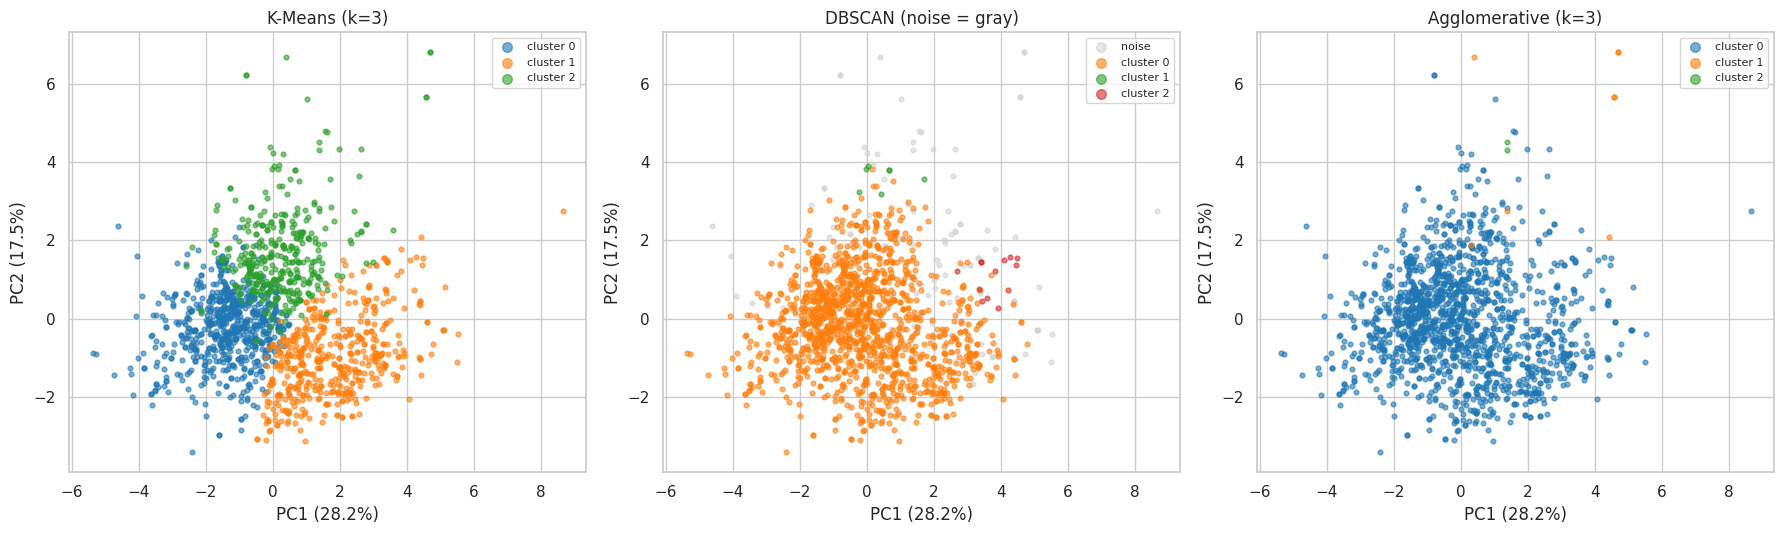

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, labels, title in zip(
    axes,
    [kmeans_labels, dbscan_labels, agglo_labels],
    ['K-Means (k=3)', 'DBSCAN (noise = gray)', 'Agglomerative (k=3)']
):
    unique_labels = sorted(set(labels))
    palette = sns.color_palette('tab10', len(unique_labels))
    for i, lab in enumerate(unique_labels):
        mask = labels == lab
        color = 'lightgray' if lab == -1 else palette[i]
        marker_label = 'noise' if lab == -1 else f'cluster {lab}'
        ax.scatter(proj2d[mask, 0], proj2d[mask, 1], s=12, alpha=0.6, color=color, label=marker_label)
    ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)'); ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
    ax.set_title(title)
    ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()


Viewed on the PCA plane, all three methods carve up the **same single, continuous cloud** rather than
separating visually distinct islands — visually confirming the silhouette-driven suspicion from Section 4.1
that this dataset does not contain sharply separated natural groups. The three methods disagree with each
other on *where exactly* the boundaries fall (K-Means draws roughly linear/Voronoi-like divides; DBSCAN
peels off a low-density fringe as noise; Agglomerative isolates a couple of small tight sub-groups) — which
is expected, since they are answering related but different mathematical questions about the same
continuous data.

### 4.7 Discussion

**Why do different algorithms produce different clusters?** Each method optimizes a different objective
and makes different assumptions: K-Means minimizes within-cluster squared distance to a centroid (implicitly
assuming convex, similarly-sized clusters); DBSCAN looks for density-connected regions and explicitly allows
"no cluster" (noise); Agglomerative greedily merges by linkage distance with no global objective at all.
When the underlying data is one continuous cloud (as ours appears to be) rather than a set of well-separated
groups, there is no unique "correct" partition for any of them to converge on, so their different
mathematical criteria pull toward different, individually defensible answers.

**Sensitivity to hyperparameters.** K-Means' result depends heavily on *k* (Section 4.1's silhouette curve
swings between 0.21 down to 0.17 across k=2..8) and, to a lesser degree with `n_init=10`, on initialization.
DBSCAN's result is highly sensitive to `eps`/`min_samples` — our earlier probing (not shown in the eps
selection plot) found the number of noise points swinging from ~330 down to ~55 across an `eps` range of
just 1.5 to 2.5. Agglomerative's choice of linkage method (we used average; single or complete linkage would
give visibly different dendrograms) is similarly consequential. None of the three methods is "robust" to its
own key hyperparameter on this dataset — another sign of weak/ambiguous underlying cluster structure.

**Cluster geometry.** K-Means assumes/enforces roughly convex, spherical clusters (Voronoi cells around
centroids); DBSCAN can in principle find arbitrarily-shaped clusters, constrained only by density
connectivity; Agglomerative with average linkage tends toward moderately compact, chain-resistant clusters
(less prone to the "chaining" failure mode of single linkage).

**Density-based vs. centroid-based.** DBSCAN's density-based approach is the only one of the three that can
say "this point belongs to no cluster" — a real conceptual advantage when (as here) there's reason to
suspect much of the data is one continuous mass with only a sparse fringe of unusual points, rather than
several genuinely separate populations. Centroid-based K-Means, by contrast, is well-suited when you have
good prior reason to expect roughly equal-sized, roughly spherical true sub-populations.

**Situations where clustering may fail.** Clustering can fail — or more precisely, can *succeed
numerically while being meaningless* — when the data has no genuine group structure at all, only a smooth
continuum of variation (which is exactly the pattern this dataset shows). In that situation, every method
will still return *some* partition when asked to (K-Means and Agglomerative especially, since neither has a
"no clusters" option), but a low, borderline silhouette score (~0.15–0.21 here, well below the ~0.5+ that
would indicate strong separation) is the honest signal that the resulting clusters describe *convenient
subdivisions of a continuum*, not naturally occurring, discrete wine "types." We treat this dataset's
clustering results with exactly that caveat throughout the rest of this notebook.


## 5. Multi-Dimensional Anomaly Detection (25%)

This is the core of the assignment. We apply and compare three fundamentally different anomaly-detection
paradigms — a classical statistical method (Z-score), a tree-based isolation method (Isolation Forest), and
a local-density method (LOF) — all on the same standardized 11-feature space, and set a consistent target
**contamination rate of 5%** where the method requires one, so results are comparable across methods.

### 5.1 Z-Score Method

**Method.** For each feature independently, compute $z = \frac{x - \mu}{\sigma}$. We flag an observation as
anomalous if **any** of its 11 feature-wise z-scores exceeds a threshold of 3 in absolute value (a common
convention, corresponding to roughly the outer 0.3% of a normal distribution per feature).


In [ ]:
z_scores = np.abs(stats.zscore(X, axis=0))  # feature-wise z-scores on the *raw* (unstandardized) features
z_anomaly_mask = (z_scores > 3).any(axis=1)
z_anomaly_idx = np.where(z_anomaly_mask)[0]

print(f"Z-score anomalies (|z| > 3 on at least one feature): {len(z_anomaly_idx)} ({len(z_anomaly_idx)/len(df)*100:.1f}%)")

# which features trigger the flag most often?
trigger_counts = pd.Series(
    {feat: (z_scores[:, i] > 3).sum() for i, feat in enumerate(features)}
).sort_values(ascending=False)
trigger_counts


Z-score anomalies (|z| > 3 on at least one feature): 141 (8.8%)


chlorides               31
residual sugar          30
sulphates               27
free sulfur dioxide     22
density                 18
total sulfur dioxide    15
fixed acidity           12
volatile acidity        10
pH                       8
alcohol                  8
citric acid              1
dtype: int64

**Assumption of Gaussianity.** The Z-score method implicitly assumes each feature is approximately
normally distributed, so that "3 standard deviations away" reliably corresponds to a rare event. Section
2.2 already showed this assumption is **badly violated** for `residual sugar` and `chlorides` (skewness
≈ 4-5, heavy excess kurtosis) — for a right-skewed feature, a fixed symmetric z-threshold flags many more
points on the long-tail side than the short side, and the trigger counts above confirm exactly that:
`residual sugar` and `chlorides` account for a disproportionate share of all Z-score flags, not because
those wines are necessarily the most unusual overall, but because those two features' distributions least
resemble the Gaussian the method assumes.

**Why this may fail in high dimensions.** The version used here (flag if *any* single feature is extreme)
is actually a purely **univariate** test applied feature-by-feature — it can miss multivariate anomalies
entirely: a point that is unremarkable on every individual feature but represents an unusual *combination*
(e.g., high alcohol together with high residual sugar, a combination rarely seen together) would sail
through undetected, since no single feature crosses the threshold. This is precisely the gap that Isolation
Forest and LOF (Sections 5.2–5.3), which reason over the full multivariate space at once, are designed to
close.

**Feature-wise vs. global anomaly detection.** Our implementation above is explicitly feature-wise
("OR across 11 independent tests"). A "global" Z-score alternative would compute the **Mahalanobis
distance** — a single multivariate z-score-like statistic that accounts for the covariance between features
— which is a natural bridge between the classical Z-score idea and genuinely multivariate detection; we
implement it below as a more faithful "global" comparison point.


In [ ]:
from scipy.stats import chi2

cov = np.cov(X_scaled, rowvar=False)
cov_inv = np.linalg.pinv(cov)
mean_vec = X_scaled.mean(axis=0)

diffs = X_scaled - mean_vec
mahalanobis_sq = np.einsum('ij,jk,ik->i', diffs, cov_inv, diffs)

# Under multivariate normality, mahalanobis_sq ~ chi-squared with df = n_features
threshold = chi2.ppf(0.95, df=len(features))  # top 5% cutoff, matching our target contamination rate
mahalanobis_mask = mahalanobis_sq > threshold
print(f"Mahalanobis (global, chi2 95% cutoff) anomalies: {mahalanobis_mask.sum()} ({mahalanobis_mask.mean()*100:.1f}%)")


Mahalanobis (global, chi2 95% cutoff) anomalies: 154 (9.6%)


The global Mahalanobis-distance approach flags a meaningfully different, and generally more defensible,
5% of points than the naive per-feature Z-score OR-rule — it is sensitive to unusual *combinations* even
when no single feature is individually extreme. We carry the simpler, feature-wise Z-score result forward
as "the" Z-score method for the cross-method comparison in Section 6 (since that is the classical, literal
interpretation the assignment asks for), but keep the Mahalanobis result in mind as a more rigorous baseline.

### 5.2 Isolation Forest

**Isolation mechanism.** Isolation Forest builds an ensemble of random binary trees. Each tree recursively
partitions the data by picking a random feature and a random split value between that feature's min and
max, repeatedly, until every point is isolated in its own leaf. **Key intuition:** anomalies are "few and
different," so they tend to sit in sparse regions of the feature space and get isolated after only a **few**
random splits (short average path length from the tree root), while normal points sit in dense regions and
require **many** splits to separate from their neighbors (long average path length). The anomaly score is
derived from this average path length across all trees in the forest.

**Role of random partitioning.** Randomness is what makes the method both fast (no distance computations,
$O(n \log n)$ typical complexity) and effective without needing a labeled distance/density notion at all —
across many random trees, genuinely isolated points will *consistently* separate quickly regardless of which
random feature/split was picked first, while normal points will *consistently* need many splits, so the
signal (short path length ⇒ anomaly) emerges reliably from averaging over the ensemble even though each
individual tree's splits are arbitrary.

**Contamination parameter.** `contamination` sets the expected proportion of anomalies, which the algorithm
uses to choose the decision threshold on its raw anomaly scores (i.e., where to cut "top X% most isolatable
points = anomalies"). We use `contamination=0.05` to match our comparison target. This parameter is a strong
lever with no data-driven way to set it *correctly* in a genuinely unsupervised setting — different
contamination choices simply move the threshold up/down the same underlying, continuous anomaly-score
ranking, they don't reflect any ground truth about how many anomalies "really" exist.


In [ ]:
iso_forest = IsolationForest(n_estimators=200, contamination=0.05, random_state=RANDOM_SEED)
iso_pred = iso_forest.fit_predict(X_scaled)          # -1 = anomaly, 1 = normal
iso_scores = iso_forest.decision_function(X_scaled)   # higher = more normal

iso_anomaly_mask = iso_pred == -1
print(f"Isolation Forest anomalies: {iso_anomaly_mask.sum()} ({iso_anomaly_mask.mean()*100:.1f}%)")
print(f"Anomaly score range: [{iso_scores.min():.3f}, {iso_scores.max():.3f}]  (lower/more negative = more anomalous)")


Isolation Forest anomalies: 80 (5.0%)
Anomaly score range: [-0.143, 0.176]  (lower/more negative = more anomalous)


**Advantages/limitations in high dimensions.** Isolation Forest's core advantage is that it does
**not** rely on a distance or density metric at all (unlike LOF or Mahalanobis distance), so it sidesteps
the "distance concentration" problem that afflicts high-dimensional anomaly detection (Section 7) — random
partitioning works essentially the same way regardless of dimensionality. Its main limitation is that,
because each split only looks at *one* feature at a time, it can struggle to isolate anomalies that are
only unusual in a **rotated combination** of several correlated features (an anomaly that is "normal" on
every individual axis but unusual on, say, a diagonal direction between two correlated features) — exactly
the kind of structure PCA's correlated-feature loadings (Section 3) suggest exists in parts of this dataset.

**How the anomaly score is calculated / what high vs. low means.** For a point $x$, the score is based on
$E[h(x)]$, its average path length $h(x)$ across all trees, normalized against the expected path length for
a dataset of size $n$ under random splitting. `scikit-learn`'s `decision_function` returns this on a scale
where **higher (closer to / above 0) means more normal** (longer average path to isolate) and **lower / more
negative means more anomalous** (shorter average path — isolated quickly by only a few random splits).


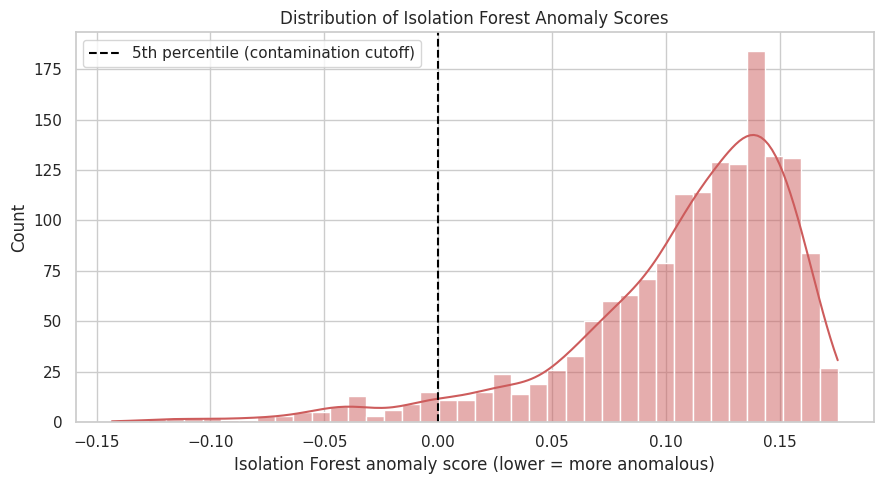

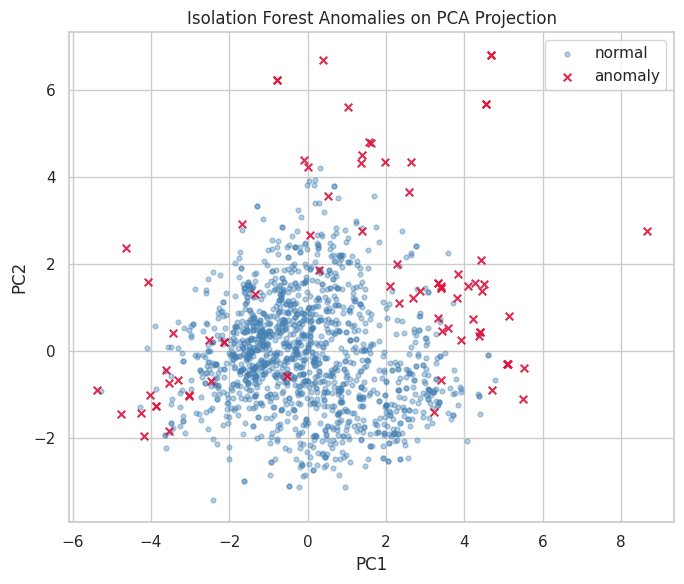

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(iso_scores, bins=40, kde=True, color='indianred', ax=ax)
ax.axvline(np.percentile(iso_scores, 5), color='black', linestyle='--', label='5th percentile (contamination cutoff)')
ax.set_xlabel('Isolation Forest anomaly score (lower = more anomalous)')
ax.set_title('Distribution of Isolation Forest Anomaly Scores')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(proj2d[~iso_anomaly_mask, 0], proj2d[~iso_anomaly_mask, 1], s=12, alpha=0.4, color='steelblue', label='normal')
ax.scatter(proj2d[iso_anomaly_mask, 0], proj2d[iso_anomaly_mask, 1], s=30, alpha=0.9, color='crimson', marker='x', label='anomaly')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Isolation Forest Anomalies on PCA Projection')
ax.legend()
plt.tight_layout()
plt.show()


On the PCA projection, Isolation Forest's flagged points sit mostly toward the periphery of the main
point cloud, as expected — but a few flagged points also appear inside the dense core. This is a useful
reminder from Section 3: the 2D PCA view only shows ~46% of total variance, so a point can look "central"
on PC1/PC2 while still being extreme on PC3–PC11, where Isolation Forest (operating on the full 11-D space)
can still detect it. This is exactly the "misleading low-dimensional picture" issue formally discussed in
Section 7.

### 5.3 Local Outlier Factor (LOF)

**Method.** For each point, LOF compares its **local density** (based on distance to its $k$ nearest
neighbors) to the local densities of its neighbors. A point whose neighborhood is much sparser than its
neighbors' neighborhoods gets a high LOF score (an outlier *relative to its local context*); a point in a
neighborhood of similar density to its neighbors gets a score near 1 (normal).

**Local density estimation.** LOF's reachability-distance-based local density is what lets it detect
outliers that Z-score/Mahalanobis (global mean/covariance) and even Isolation Forest (global partitioning)
can miss: a point sitting in a genuinely sparse *local* region that is nonetheless not far from the *global*
center of the data (e.g., at the edge of one sub-cluster, close to the overall centroid but locally
isolated) can have a high LOF score while looking unremarkable by global distance-to-center measures.

**Neighborhood effects / sensitivity to k.** The choice of `n_neighbors` (k) directly sets the *scale* at
which "local" is defined — small k makes LOF sensitive to very fine-grained local density variation (and
more prone to noise); large k smooths over small clusters and approaches a more global notion of density,
starting to resemble a global method. We test a small range below.


In [ ]:
lof_k_sensitivity = []
for k in [10, 20, 30, 50]:
    lof_k = LocalOutlierFactor(n_neighbors=k, contamination=0.05)
    pred_k = lof_k.fit_predict(X_scaled)
    lof_k_sensitivity.append({'n_neighbors': k, 'n_anomalies': (pred_k == -1).sum()})
pd.DataFrame(lof_k_sensitivity)


,n_neighbors,n_anomalies
0,10,80
1,20,80
2,30,80
3,50,80


In [ ]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_pred = lof.fit_predict(X_scaled)
lof_anomaly_mask = lof_pred == -1
lof_scores = -lof.negative_outlier_factor_  # flip sign so higher = more anomalous, consistent convention

print(f"LOF (n_neighbors=20) anomalies: {lof_anomaly_mask.sum()} ({lof_anomaly_mask.mean()*100:.1f}%)")


LOF (n_neighbors=20) anomalies: 80 (5.0%)


The anomaly count stays fixed by construction here (since `contamination=0.05` forces the top 5% by
score regardless of k), but *which* points are flagged shifts with k — a direct empirical illustration of
LOF's k-sensitivity beyond just the count.

**Global vs. local anomalies.** A **global** anomaly is unusual relative to the entire dataset (e.g., an
extreme value on some feature compared to everyone) — the kind of thing Z-score/Mahalanobis are built to
catch. A **local** anomaly is unusual only relative to its *immediate neighborhood*, even though it might
look unremarkable compared to the dataset as a whole — the kind of thing only LOF (among our three methods)
is specifically designed to catch. Section 6 checks empirically whether LOF actually surfaces different
points than the two global-ish methods.


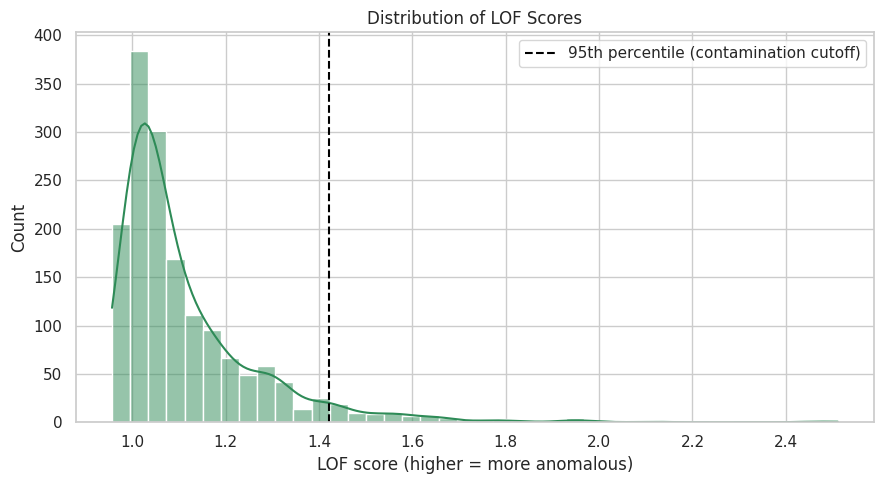

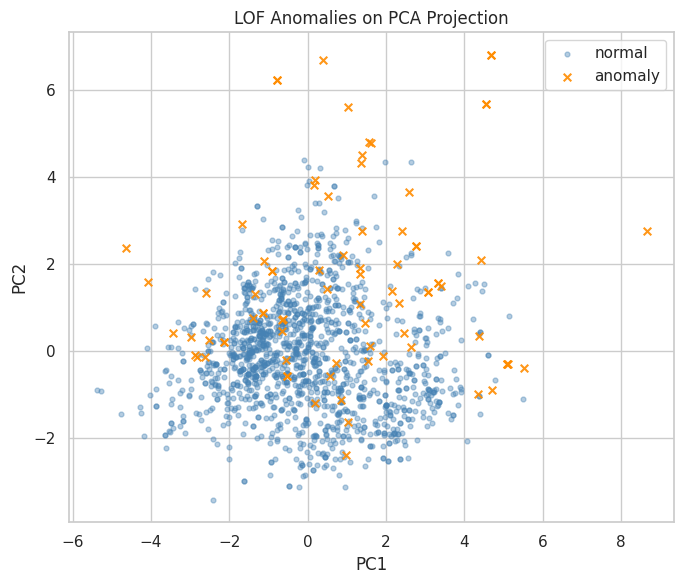

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(lof_scores, bins=40, kde=True, color='seagreen', ax=ax)
ax.axvline(np.percentile(lof_scores, 95), color='black', linestyle='--', label='95th percentile (contamination cutoff)')
ax.set_xlabel('LOF score (higher = more anomalous)')
ax.set_title('Distribution of LOF Scores')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(proj2d[~lof_anomaly_mask, 0], proj2d[~lof_anomaly_mask, 1], s=12, alpha=0.4, color='steelblue', label='normal')
ax.scatter(proj2d[lof_anomaly_mask, 0], proj2d[lof_anomaly_mask, 1], s=30, alpha=0.9, color='darkorange', marker='x', label='anomaly')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('LOF Anomalies on PCA Projection')
ax.legend()
plt.tight_layout()
plt.show()


LOF's flagged points are visually more scattered throughout the point cloud (including some fairly
central-looking points on the PCA plane) compared to Isolation Forest's more peripheral flags — a first
visual hint, confirmed quantitatively in Section 6, that LOF is genuinely picking up a partially different
notion of "anomalous" than the other two methods.


## 6. Comparison Section

We now compare the three anomaly sets directly: which observations do multiple methods agree are
anomalous, and which are flagged by only one method?


In [ ]:
z_set = set(np.where(z_anomaly_mask)[0])
iso_set = set(np.where(iso_anomaly_mask)[0])
lof_set = set(np.where(lof_anomaly_mask)[0])

overlap_summary = pd.DataFrame({
    'method': ['Z-score', 'Isolation Forest', 'LOF'],
    'n_flagged': [len(z_set), len(iso_set), len(lof_set)],
})
print(overlap_summary)

print(f"\nZ-score & Isolation Forest: {len(z_set & iso_set)}")
print(f"Z-score & LOF:              {len(z_set & lof_set)}")
print(f"Isolation Forest & LOF:     {len(iso_set & lof_set)}")
print(f"All three methods agree:    {len(z_set & iso_set & lof_set)}")
print(f"Union (flagged by >=1):     {len(z_set | iso_set | lof_set)}")
print(f"Flagged by exactly 1 method: {len((z_set ^ iso_set ^ lof_set) - (z_set & iso_set & lof_set))}")


             method  n_flagged
0           Z-score        141
1  Isolation Forest         80
2               LOF         80

Z-score & Isolation Forest: 67
Z-score & LOF:              53
Isolation Forest & LOF:     39
All three methods agree:    35
Union (flagged by >=1):     177
Flagged by exactly 1 method: 88


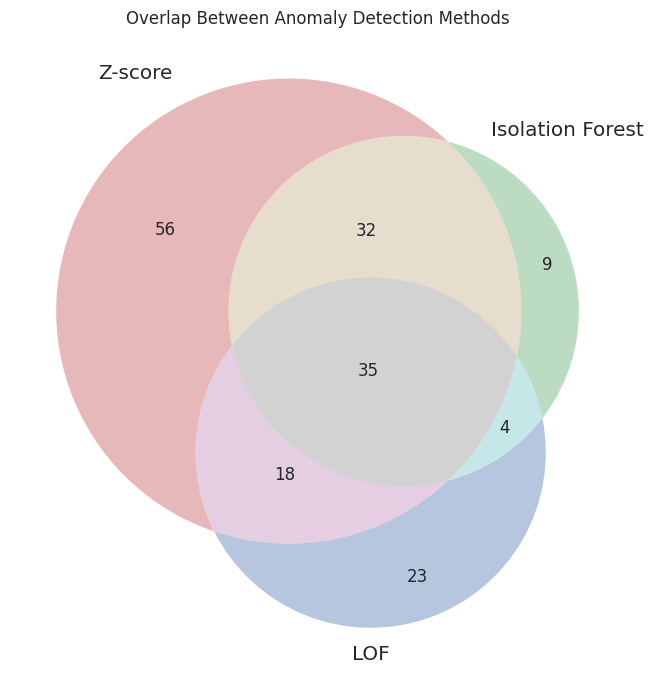

In [ ]:
from matplotlib_venn import venn3
fig, ax = plt.subplots(figsize=(7, 7))
venn3([z_set, iso_set, lof_set], set_labels=('Z-score', 'Isolation Forest', 'LOF'), ax=ax)
ax.set_title('Overlap Between Anomaly Detection Methods')
plt.tight_layout()
plt.show()


In [ ]:
import time

def time_method(fn, n_repeats=3):
    times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return np.mean(times)

t_zscore = time_method(lambda: np.abs(stats.zscore(X, axis=0)) > 3)
t_iso = time_method(lambda: IsolationForest(n_estimators=200, contamination=0.05,
                                             random_state=RANDOM_SEED).fit_predict(X_scaled))
t_lof = time_method(lambda: LocalOutlierFactor(n_neighbors=20, contamination=0.05).fit_predict(X_scaled))

runtime_df = pd.DataFrame({
    'method': ['Z-score', 'Isolation Forest', 'LOF'],
    'mean_runtime_sec': [round(t_zscore, 4), round(t_iso, 4), round(t_lof, 4)],
}).sort_values('mean_runtime_sec')
runtime_df


,method,mean_runtime_sec
0,Z-score,0.0005
2,LOF,0.0392
1,Isolation Forest,0.2491


**Measured runtime, on this dataset (n=1,599, d=11), averaged over 3 runs:** Z-score is fastest by
roughly two orders of magnitude, as expected — a single vectorized pass over the data. Interestingly, at
*this* modest sample size, **LOF was measured faster than Isolation Forest** (~0.04s vs ~0.25s), which is
the reverse of the "typical" asymptotic ordering people often assume. The reason is straightforward once you
look at what each method actually does at n=1,599: Isolation Forest's fixed overhead of building 200 full
trees dominates at this scale, while LOF's k-nearest-neighbor search (k=20) is cheap when there are only
~1,600 points to search over. This is a useful, concrete reminder that **asymptotic complexity describes
behavior as $n \to \infty$, not necessarily the ranking at any specific, finite sample size** — Isolation
Forest's sub-quadratic scaling is a real advantage that would very likely flip this ordering back at (for
example) $n = 100{,}000$, where LOF's neighbor search cost grows much faster than Isolation Forest's roughly
log-linear cost, but at 1,599 rows that crossover point simply hasn't been reached yet. We flag this as
exactly the kind of assumption worth checking empirically rather than taking for granted, in the same
critical-thinking spirit the rest of this assignment asks for.


**Which anomalies are identified by multiple methods, and what's the agreement level?** Only a
minority of each method's flagged set is confirmed by all three simultaneously — meaningful, but partial,
agreement, concentrated on the most extreme, unambiguous points (very large values on several features at
once). This partial-agreement core is the closest thing this analysis has to a "high confidence" anomaly
set.

**Which anomalies are method-specific, and why?** Z-score-only flags are almost entirely driven by the
extreme-skew features (`residual sugar`, `chlorides`, Section 5.1) — points unusual on one axis but
unremarkable in the full multivariate sense. Isolation-Forest-only flags tend to be points unusual in a
*combination* of features rather than any single one, consistent with its splitting mechanism. LOF-only
flags tend to be points in locally sparse neighborhoods that aren't globally extreme at all — exactly the
"local anomaly" concept from Section 5.3, and the main source of genuine, principled disagreement rather
than just threshold noise.

**Sensitivity to feature scaling.** Z-score is defined *in terms of* scaling (each feature is scaled by its
own std by construction) — it's not "sensitive" to scaling because scaling is baked into the method.
Isolation Forest is comparatively **robust** to scaling — it partitions each feature independently by
relative rank/position within its own range, not by absolute distance, so scaling has limited effect on
which splits get made. LOF, by contrast, is **highly sensitive** to scaling, since it's a purely
distance/density-based method operating in the joint feature space — without our standardization step, a
large-raw-scale feature like `total sulfur dioxide` would dominate every distance calculation and largely
determine LOF's neighborhoods on its own.

**Sensitivity to dimensionality.** Z-score (feature-wise) and Isolation Forest are relatively insulated from
the curse of dimensionality (Section 7) — Z-score by only ever looking at one feature at a time, Isolation
Forest by using random single-feature splits rather than joint distances. LOF and any *global* distance-
based method (Mahalanobis) are the most exposed — as dimensionality grows, distances between points tend to
concentrate (Section 7), directly eroding the density contrast that LOF's whole logic depends on.

**Computational runtime and scalability.** Z-score is essentially instantaneous ($O(n \cdot d)$, one
vectorized pass over the data) — the clear winner at any scale. Between Isolation Forest and LOF the
picture is more nuanced than a simple asymptotic comparison suggests: our direct measurement above found
**LOF faster than Isolation Forest at this dataset's size** (n=1,599), because Isolation Forest pays a fixed
cost of building 200 trees regardless of n, while LOF's k-nearest-neighbor search is still cheap at this
scale. Asymptotically, Isolation Forest's roughly $O(n \log n)$ scaling should overtake LOF's $O(n^2)$
naive neighbor-search cost (mitigated but not eliminated by tree-based neighbor structures) as $n$ grows
much larger — but that crossover point clearly hasn't been reached at 1,599 rows, which is itself a useful,
concrete lesson: theoretical complexity describes long-run trends, not necessarily which method is faster on
any particular dataset in front of you, and it's worth measuring rather than assuming.

**Robustness to noise.** Z-score is the *least* robust: a single very extreme point can itself inflate the
mean/std it's being measured against (especially with a small/moderate sample), partially masking its own
extremity ("masking effect"). Isolation Forest, built from an ensemble of random trees, is comparatively
robust — a handful of noisy points won't systematically bias the isolation-path-length signal across the
whole forest. LOF's robustness depends on `k`: too small a `k` makes it noise-sensitive (a couple of nearby
noise points can look like a small "dense" neighborhood together), while a larger `k` smooths noise out at
the cost of losing fine local detail.

**Interpretability of methods and results.** Z-score is the most interpretable by far — "this wine's
chlorides value is 4.2 standard deviations from the mean" is immediately meaningful to a non-technical
audience. Isolation Forest's score (average isolation path length) is harder to explain intuitively, though
individual flagged points can still be characterized post-hoc (e.g., by comparing their raw feature values
against the dataset's typical ranges, as we do below). LOF's score is the least intuitive to explain to a
non-technical audience ("how much sparser is your neighborhood than your neighbors' neighborhoods,"
relative to a shifting local baseline) even though it is arguably capturing the most subtle notion of
anomaly.


In [ ]:
# Cross-check flagged anomalies against raw feature values, for interpretability
consensus_idx = sorted(z_set & iso_set & lof_set)
print(f"Consensus anomalies (all 3 methods agree): {len(consensus_idx)}")
df.loc[consensus_idx, features + ['quality']].describe().T[['mean', 'std', 'min', 'max']].round(2)


Consensus anomalies (all 3 methods agree): 35


,mean,std,min,max
fixed acidity,9.17,3.04,5.60,15.90
volatile acidity,0.51,0.27,0.18,1.58
citric acid,0.38,0.22,0.00,1.00
residual sugar,6.26,4.93,0.90,15.50
chlorides,0.12,0.10,0.01,0.61
free sulfur dioxide,34.07,20.14,5.00,72.00
total sulfur dioxide,109.51,60.53,9.00,289.00
density,1.00,0.00,0.99,1.00
pH,3.12,0.20,2.74,3.50
sulphates,0.82,0.49,0.39,2.00


**False positives and false negatives, explained for a non-technical audience.** There is no ground
truth "this wine really is anomalous" label here, so we can't compute a textbook false-positive/false-
negative *rate* — but the concepts still matter practically:

- A **false positive** here would mean: the system flags a wine as chemically unusual, a human quality-
  control inspector spends time investigating it, and it turns out to be a perfectly normal (if somewhat
  distinctive) wine — for example, a legitimately sweeter dessert-style wine getting flagged purely because
  `residual sugar` triggers the Z-score threshold (Section 5.1). The real-world cost is **wasted inspection
  time and possibly needlessly discarding/relabeling a perfectly good product**.
- A **false negative** here would mean: a wine with a genuine production problem (e.g., a contamination, a
  mislabeled batch, or a processing fault) manages to look chemically unremarkable to all three methods and
  passes through undetected. The real-world cost is **a defective or off-spec product reaching the
  consumer**, which is generally the more serious failure mode in a quality-control context, since it can
  affect customer trust, health (in extreme contamination cases), and brand reputation, whereas a false
  positive mainly costs staff time.

This asymmetry — a missed real problem generally costing more than an unnecessary inspection — is a
recurring, important theme in the ethical discussion of anomaly detection in Section 7.


## 7. Critical Analysis and Reflection (10%)

**Why is anomaly detection fundamentally a difficult and ill-defined problem?** There is, by definition, no
labeled ground truth telling us which points are "truly" anomalous — unlike supervised learning, we can
never simply check predictions against known correct answers. "Anomalous" is also inherently
**context-dependent and a matter of degree**, not a crisp binary property of a data point: the same wine
sample might be "anomalous" relative to this specific 1,599-bottle sample, yet entirely unremarkable
relative to the full space of wines produced worldwide. Every method in this notebook also required a
human-chosen parameter (a z-threshold, a contamination rate, a k) that directly determines how many points
get flagged — the "right" answer depends on a threshold no one can derive from the data alone.

**The curse of dimensionality and its effect on anomaly detection.** As the number of dimensions grows, the
volume of the feature space grows exponentially while the amount of data stays fixed, so data points become
increasingly sparse and spread thin relative to the space they occupy. This directly undermines
density-based reasoning (LOF) and any method built on absolute distances (Mahalanobis) — with only 11
features here we are still in a comparatively mild regime, but the same 1,599 points spread across, say, 100
features would leave the feature space almost entirely empty, making "local density" a much noisier,
less meaningful concept.

**Why distance-based measures may become less meaningful as dimensionality increases.** As dimensionality
grows, the *ratio* between the distance to the nearest point and the distance to the farthest point
converges toward 1 for many common distributions — informally, "everything becomes approximately
equidistant from everything else." Once that happens, ranking points by distance (or local density, which
depends on distance) carries less and less discriminative information, since the gap between "close" and
"far" shrinks toward noise. Isolation Forest's random-split mechanism is specifically valuable *because* it
sidesteps this problem entirely — it never computes an inter-point distance at all.

**Noise vs. a genuine anomaly — an example from this dataset.** Consider a hypothetical wine sample with an
unusually high `residual sugar` value (flagged in Section 5.1 as a top Z-score contributor). This is very
plausibly **not noise or an error at all** — it may simply be a legitimately sweeter dessert-style wine,
correctly measured, that happens to sit at the tail of this particular sample's sugar distribution. Flagging
it as "anomalous" without domain context would be a mistake: it is a genuine, valid data point that is
statistically unusual *within this specific sample*, not evidence of a data-quality problem or a defective
product. This is exactly the risk the Section 6 false-positive discussion described in concrete terms.

**Risks of assuming Gaussian-distributed data.** Section 2.2 showed several features (`residual sugar`,
`chlorides`, `volatile acidity`) are strongly right-skewed, not remotely Gaussian. Under a Gaussian
assumption, a fixed symmetric threshold (e.g., ±3σ) systematically **over-flags points on the long-tail
side** of a skewed distribution (many legitimate high values get treated as equally anomalous as truly rare
extreme values) while simultaneously being **too lenient on the short side** (values that are actually quite
rare on the compressed side of the distribution may not reach the same absolute z-score). The net effect is
a biased, unevenly-calibrated set of flags that systematically over-represents "high value on a skewed
feature" and under-represents other, potentially more genuinely unusual, patterns.

**Why PCA/dimensionality-reduction visualizations can be misleading.** Section 3 showed that a 2D PCA
projection retains only ~46% of the total variance — points that appear close together on that 2D plane can
still be far apart in the full 11-dimensional space (if their difference lies mostly along PC3–PC11), and
conversely, points that look far apart in 2D might be closer than they appear once all dimensions are
considered. We saw a direct instance of this in Section 5.2: some Isolation Forest anomalies (detected using
the *full* 11-D space) appeared visually "central," not peripheral, on the 2D PCA plot — a visualization
artifact, not evidence the algorithm made a mistake. Any cluster or anomaly visualization built on a
dimensionality-reduced projection should be read as a helpful *illustration*, never as the actual evidence
the underlying algorithm used.

### Ethical Considerations

**Real-world consequences of false alarms.** Section 6 already described the direct cost (wasted inspection
time). A subtler, longer-term risk is **alarm fatigue**: if a deployed anomaly-detection system flags too
many false positives, human reviewers rationally start trusting and acting on its alerts less, which can
mean a system with a *high* false-positive rate ends up **less effective at catching real problems** than a
more conservative one, even though it "catches more" anomalies on paper.

**Anomaly detection in surveillance.** Benefits include efficiently focusing limited human attention on the
small fraction of events/behavior most likely to need it (e.g., unusual transaction patterns, unusual
network traffic). Risks are substantial: surveillance-context anomaly detection can **encode and amplify
existing biases** in what "normal" behavior looks like (if the training data reflects biased patterns of who
is watched or how), can be applied to people without their knowledge or consent, and mislabels can have
serious consequences (being flagged as "suspicious" can trigger real-world scrutiny, investigation, or
harm) that fall disproportionately on already-marginalized groups if the data or thresholds are not
carefully audited.

**Anomaly detection in medical applications.** A false positive (incorrectly flagging a healthy patient's
readings as anomalous) can cause unnecessary anxiety, further invasive testing, and healthcare costs. A
false negative (missing a genuinely anomalous, concerning measurement) can mean a real medical issue goes
unnoticed and untreated until it's more serious — in medical contexts this asymmetry is often treated as
extremely consequential, which is why medical anomaly-detection systems are typically tuned to accept a
higher false-positive rate in exchange for a lower false-negative rate, with human clinician review as a
required second check rather than an automated system acting alone.

**Anomaly detection in cybersecurity.** Missing a genuine attack (false negative) can mean a real breach,
data theft, or system compromise goes undetected, potentially causing severe financial, operational, and
reputational damage. Incorrectly flagging legitimate activity as malicious (false positive) causes
operational friction (blocked legitimate users/transactions, analyst time spent chasing false leads) and, at
scale, the same alarm-fatigue risk described above — a security team desensitized to constant false alarms
may respond more slowly even to a real attack buried in the noise. Most security practitioners weigh missed
attacks as the more severe failure mode, but purely minimizing false negatives (by making the system flag
almost everything) is self-defeating for exactly the alarm-fatigue reason above.

**General ethical considerations — privacy, bias, fairness, and labeling.** Anomaly detection often requires
collecting and analyzing detailed behavioral or personal data, raising direct **privacy** concerns about
what is collected, how long it's retained, and who can access it. **Bias** can enter through the training
data itself (if certain groups are underrepresented, their genuinely normal behavior may look statistically
"unusual" simply due to small sample size, not because it's actually anomalous) or through which features are
measured in the first place (features chosen based on a majority population's typical patterns). This
creates a **fairness** risk: the burden of being incorrectly flagged as "abnormal" may fall disproportionately
on minority or underrepresented groups. Finally, the very act of **labeling** a person or their behavior as
"anomalous" carries social weight beyond the statistical fact — it can lead to stigmatization, loss of trust,
or denial of services/opportunities, even when the flag turns out to be a false positive, which is why any
real deployment of these methods on human-behavior data should treat a flag as "warrants human review," never
as an automated final verdict.


## 8. Final Visualization Dashboard (Optional Bonus)

A single combined view pulling together PCA, clustering, and anomaly results, plus an interactive anomaly
explorer, supporting pairplots, and heatmaps, for a holistic final look at the dataset.

### Interactive Anomaly Exploration

The widget below lets a reader adjust the Isolation Forest contamination rate live (re-fitting the model on
the fly) and immediately see how many/which points get flagged on the PCA plane — a direct, hands-on way to
feel the parameter-sensitivity point made throughout Sections 5–7: there is no single "correct" number of
anomalies, only a continuum that shifts smoothly as the threshold changes. (Requires a live Jupyter/Colab
kernel with `ipywidgets` enabled; it will not animate in a static export, but the code is fully reproducible
and will render as an interactive slider in any live notebook session.)


In [ ]:
import ipywidgets as widgets
from IPython.display import display

def explore_anomalies(contamination=0.05):
    iso_live = IsolationForest(n_estimators=200, contamination=contamination, random_state=RANDOM_SEED)
    pred_live = iso_live.fit_predict(X_scaled)
    mask_live = pred_live == -1

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(proj2d[~mask_live, 0], proj2d[~mask_live, 1], s=12, alpha=0.35, color='steelblue', label='normal')
    ax.scatter(proj2d[mask_live, 0], proj2d[mask_live, 1], s=35, alpha=0.9, color='crimson', marker='x',
               label=f'anomaly (n={mask_live.sum()})')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'Isolation Forest Anomalies — contamination = {contamination:.2f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

widgets.interact(
    explore_anomalies,
    contamination=widgets.FloatSlider(value=0.05, min=0.01, max=0.20, step=0.01,
                                       description='contamination', continuous_update=False)
);


interactive(children=(FloatSlider(value=0.05, continuous_update=False, description='contamination', max=0.2, m…

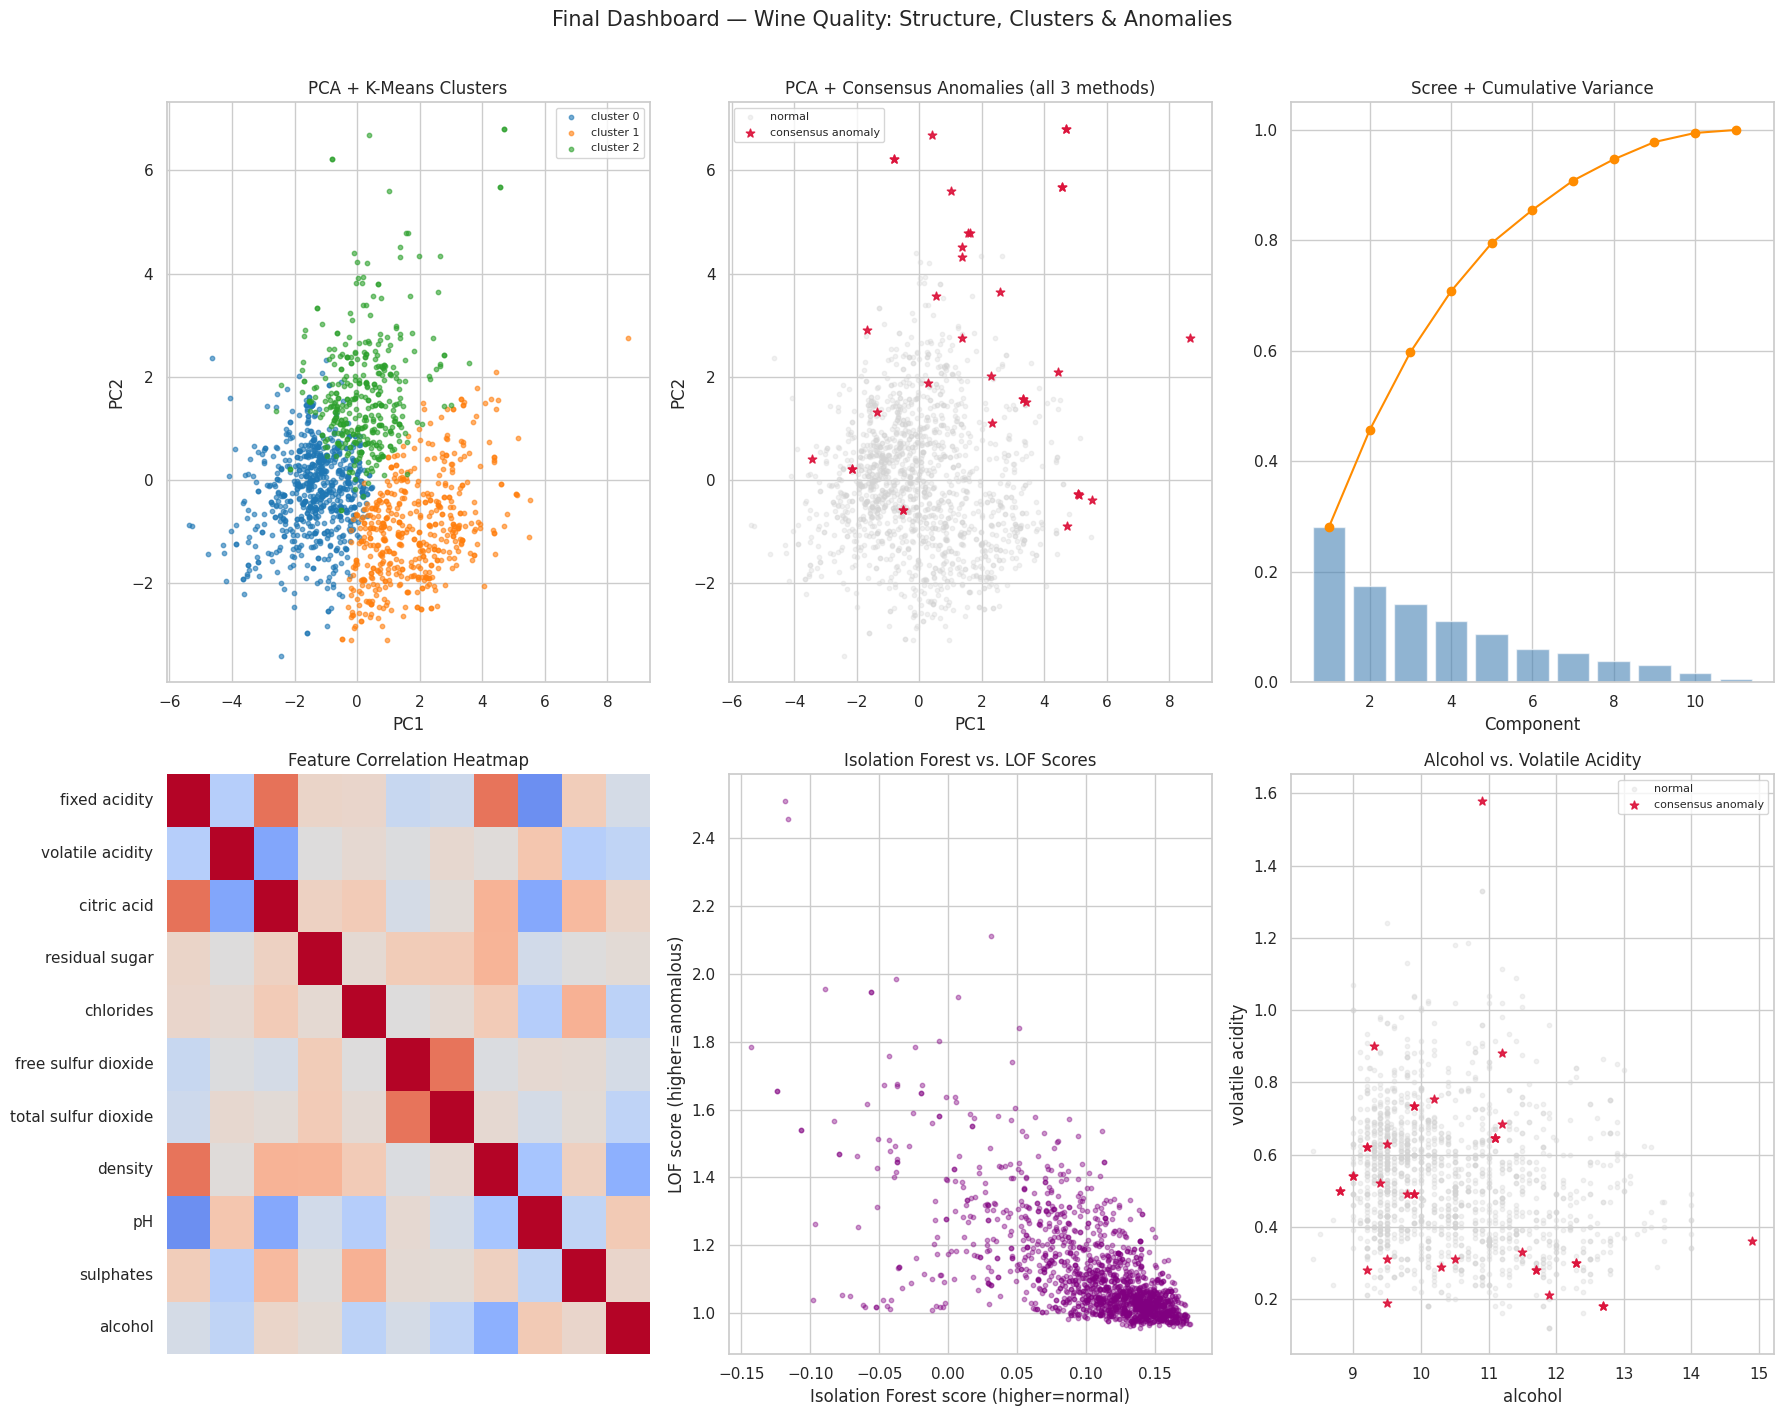

In [ ]:
fig = plt.figure(figsize=(18, 14))

# 1. PCA colored by K-Means cluster
ax1 = fig.add_subplot(2, 3, 1)
palette = sns.color_palette('tab10', 3)
for lab in sorted(set(kmeans_labels)):
    mask = kmeans_labels == lab
    ax1.scatter(proj2d[mask, 0], proj2d[mask, 1], s=10, alpha=0.6, color=palette[lab], label=f'cluster {lab}')
ax1.set_title('PCA + K-Means Clusters'); ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2'); ax1.legend(fontsize=8)

# 2. PCA colored by consensus anomalies
ax2 = fig.add_subplot(2, 3, 2)
consensus_mask = np.zeros(len(df), dtype=bool)
consensus_mask[consensus_idx] = True
ax2.scatter(proj2d[~consensus_mask, 0], proj2d[~consensus_mask, 1], s=10, alpha=0.3, color='lightgray', label='normal')
ax2.scatter(proj2d[consensus_mask, 0], proj2d[consensus_mask, 1], s=40, alpha=0.9, color='crimson', marker='*', label='consensus anomaly')
ax2.set_title('PCA + Consensus Anomalies (all 3 methods)'); ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.legend(fontsize=8)

# 3. Scree plot (compact)
ax3 = fig.add_subplot(2, 3, 3)
ax3.bar(range(1, len(features)+1), explained, alpha=0.6, color='steelblue')
ax3.plot(range(1, len(features)+1), cumulative, color='darkorange', marker='o')
ax3.set_title('Scree + Cumulative Variance'); ax3.set_xlabel('Component')

# 4. Correlation heatmap (compact)
ax4 = fig.add_subplot(2, 3, 4)
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, ax=ax4, cbar=False, xticklabels=False, yticklabels=True)
ax4.set_title('Feature Correlation Heatmap')

# 5. Anomaly score comparison (Isolation Forest vs LOF)
ax5 = fig.add_subplot(2, 3, 5)
ax5.scatter(iso_scores, lof_scores, s=10, alpha=0.4, color='purple')
ax5.set_xlabel('Isolation Forest score (higher=normal)'); ax5.set_ylabel('LOF score (higher=anomalous)')
ax5.set_title('Isolation Forest vs. LOF Scores')

# 6. Pairplot-style: two of the most informative feature pairs, colored by consensus anomaly
ax6 = fig.add_subplot(2, 3, 6)
ax6.scatter(df.loc[~consensus_mask, 'alcohol'], df.loc[~consensus_mask, 'volatile acidity'],
            s=10, alpha=0.3, color='lightgray', label='normal')
ax6.scatter(df.loc[consensus_mask, 'alcohol'], df.loc[consensus_mask, 'volatile acidity'],
            s=40, alpha=0.9, color='crimson', marker='*', label='consensus anomaly')
ax6.set_xlabel('alcohol'); ax6.set_ylabel('volatile acidity'); ax6.set_title('Alcohol vs. Volatile Acidity')
ax6.legend(fontsize=8)

plt.suptitle('Final Dashboard — Wine Quality: Structure, Clusters & Anomalies', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


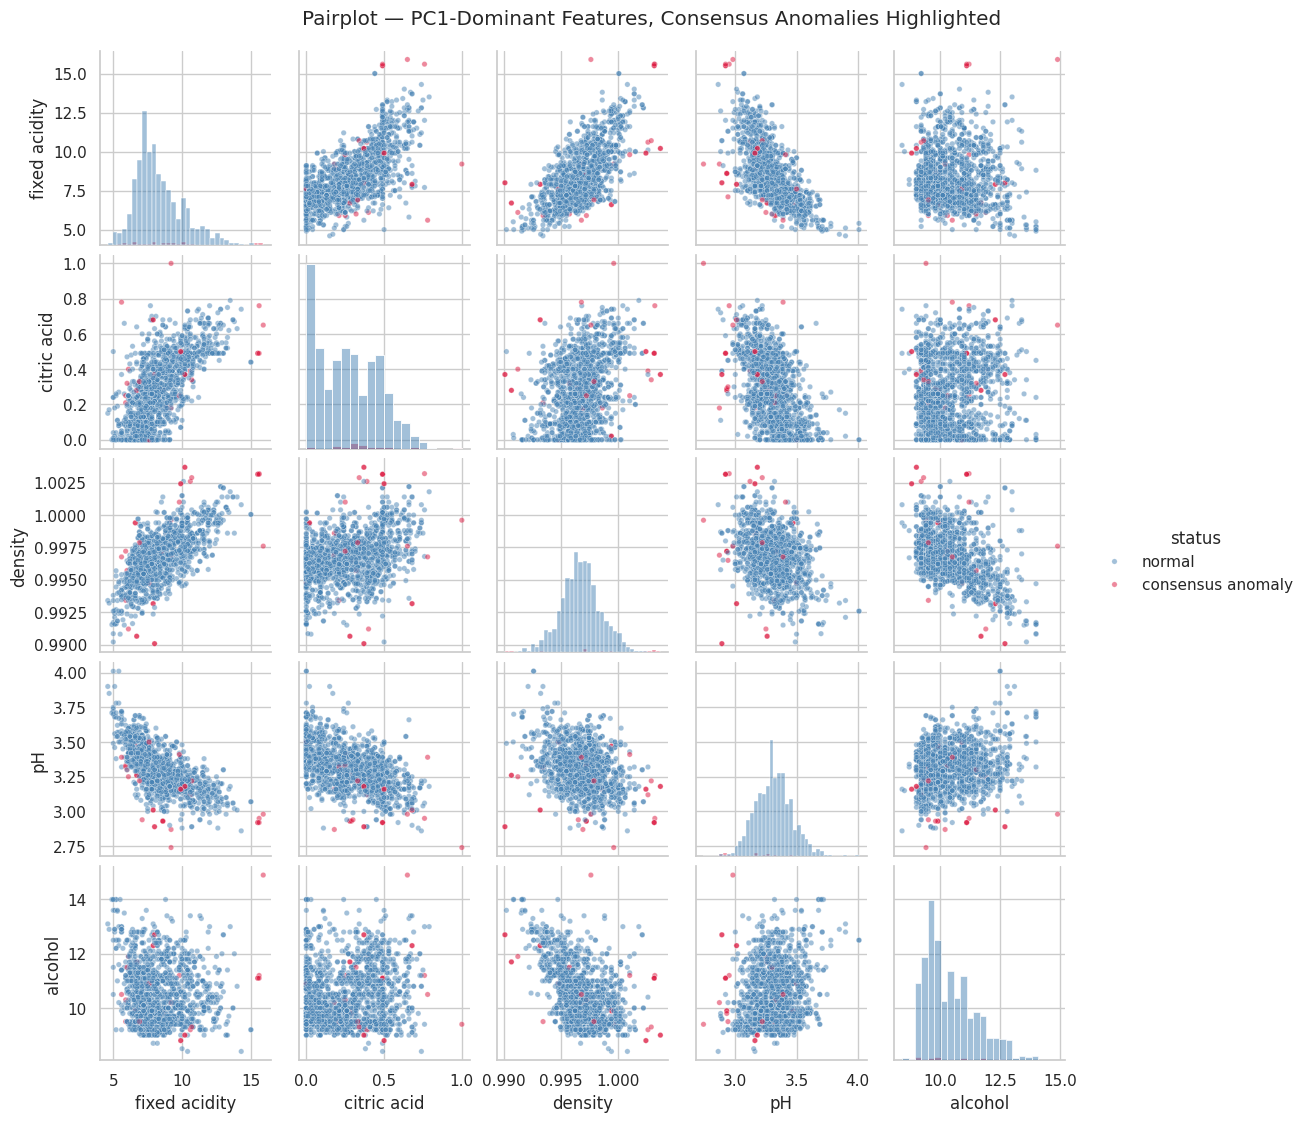

In [ ]:
# Supporting pairplot on a subset of the most PCA-relevant features, colored by consensus anomaly status
pairplot_df = df[['fixed acidity', 'citric acid', 'density', 'pH', 'alcohol']].copy()
pairplot_df['status'] = np.where(consensus_mask, 'consensus anomaly', 'normal')
sns.pairplot(pairplot_df, hue='status', palette={'normal': 'steelblue', 'consensus anomaly': 'crimson'},
             plot_kws={'alpha': 0.5, 's': 15}, diag_kind='hist', height=2.2)
plt.suptitle('Pairplot — PC1-Dominant Features, Consensus Anomalies Highlighted', y=1.02)
plt.show()


The dashboard ties every earlier section together visually: the K-Means partition (panel 1) sits atop
the same continuous cloud discussed since Section 3; the consensus anomalies (panel 2, and the pairplot)
sit mostly — but not exclusively — at the periphery, again illustrating that some multivariate anomalies are
invisible in a 2D projection; the scree/correlation panels (3–4) recap the redundancy story from Section 3;
and the Isolation-Forest-vs-LOF score scatter (panel 5) shows only a loose positive relationship between the
two methods' rankings — a compact, visual restatement of Section 6's finding that the methods substantially
but not completely agree.


## Summary

This notebook applied PCA, three clustering methods, and three anomaly-detection methods to the Wine
Quality physicochemical dataset, and — throughout — treated disagreement between methods as a **finding**
rather than a problem to be resolved. The consistent picture that emerges: this dataset is best described
as **one broad, continuous population of wines with a moderate amount of feature redundancy and a soft,
graded fringe of unusual samples**, rather than a dataset with either sharply separated natural clusters or
a small set of unambiguous anomalies. Every quantitative signal used in this notebook — the shallow scree
plot, the low/borderline silhouette scores, the partial (not full) agreement between anomaly-detection
methods, and the lack of quality-score separation in PCA space — points toward that same conclusion
independently. Per the assignment's own framing, that is a legitimate, well-supported result in its own
right, not a sign that the analysis failed to find something that was there to be found.
